In [ ]:
pip install biopython pandas numpy matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 35.0 MB/s eta 0:00:00


Execution complete! Rendering outputs:



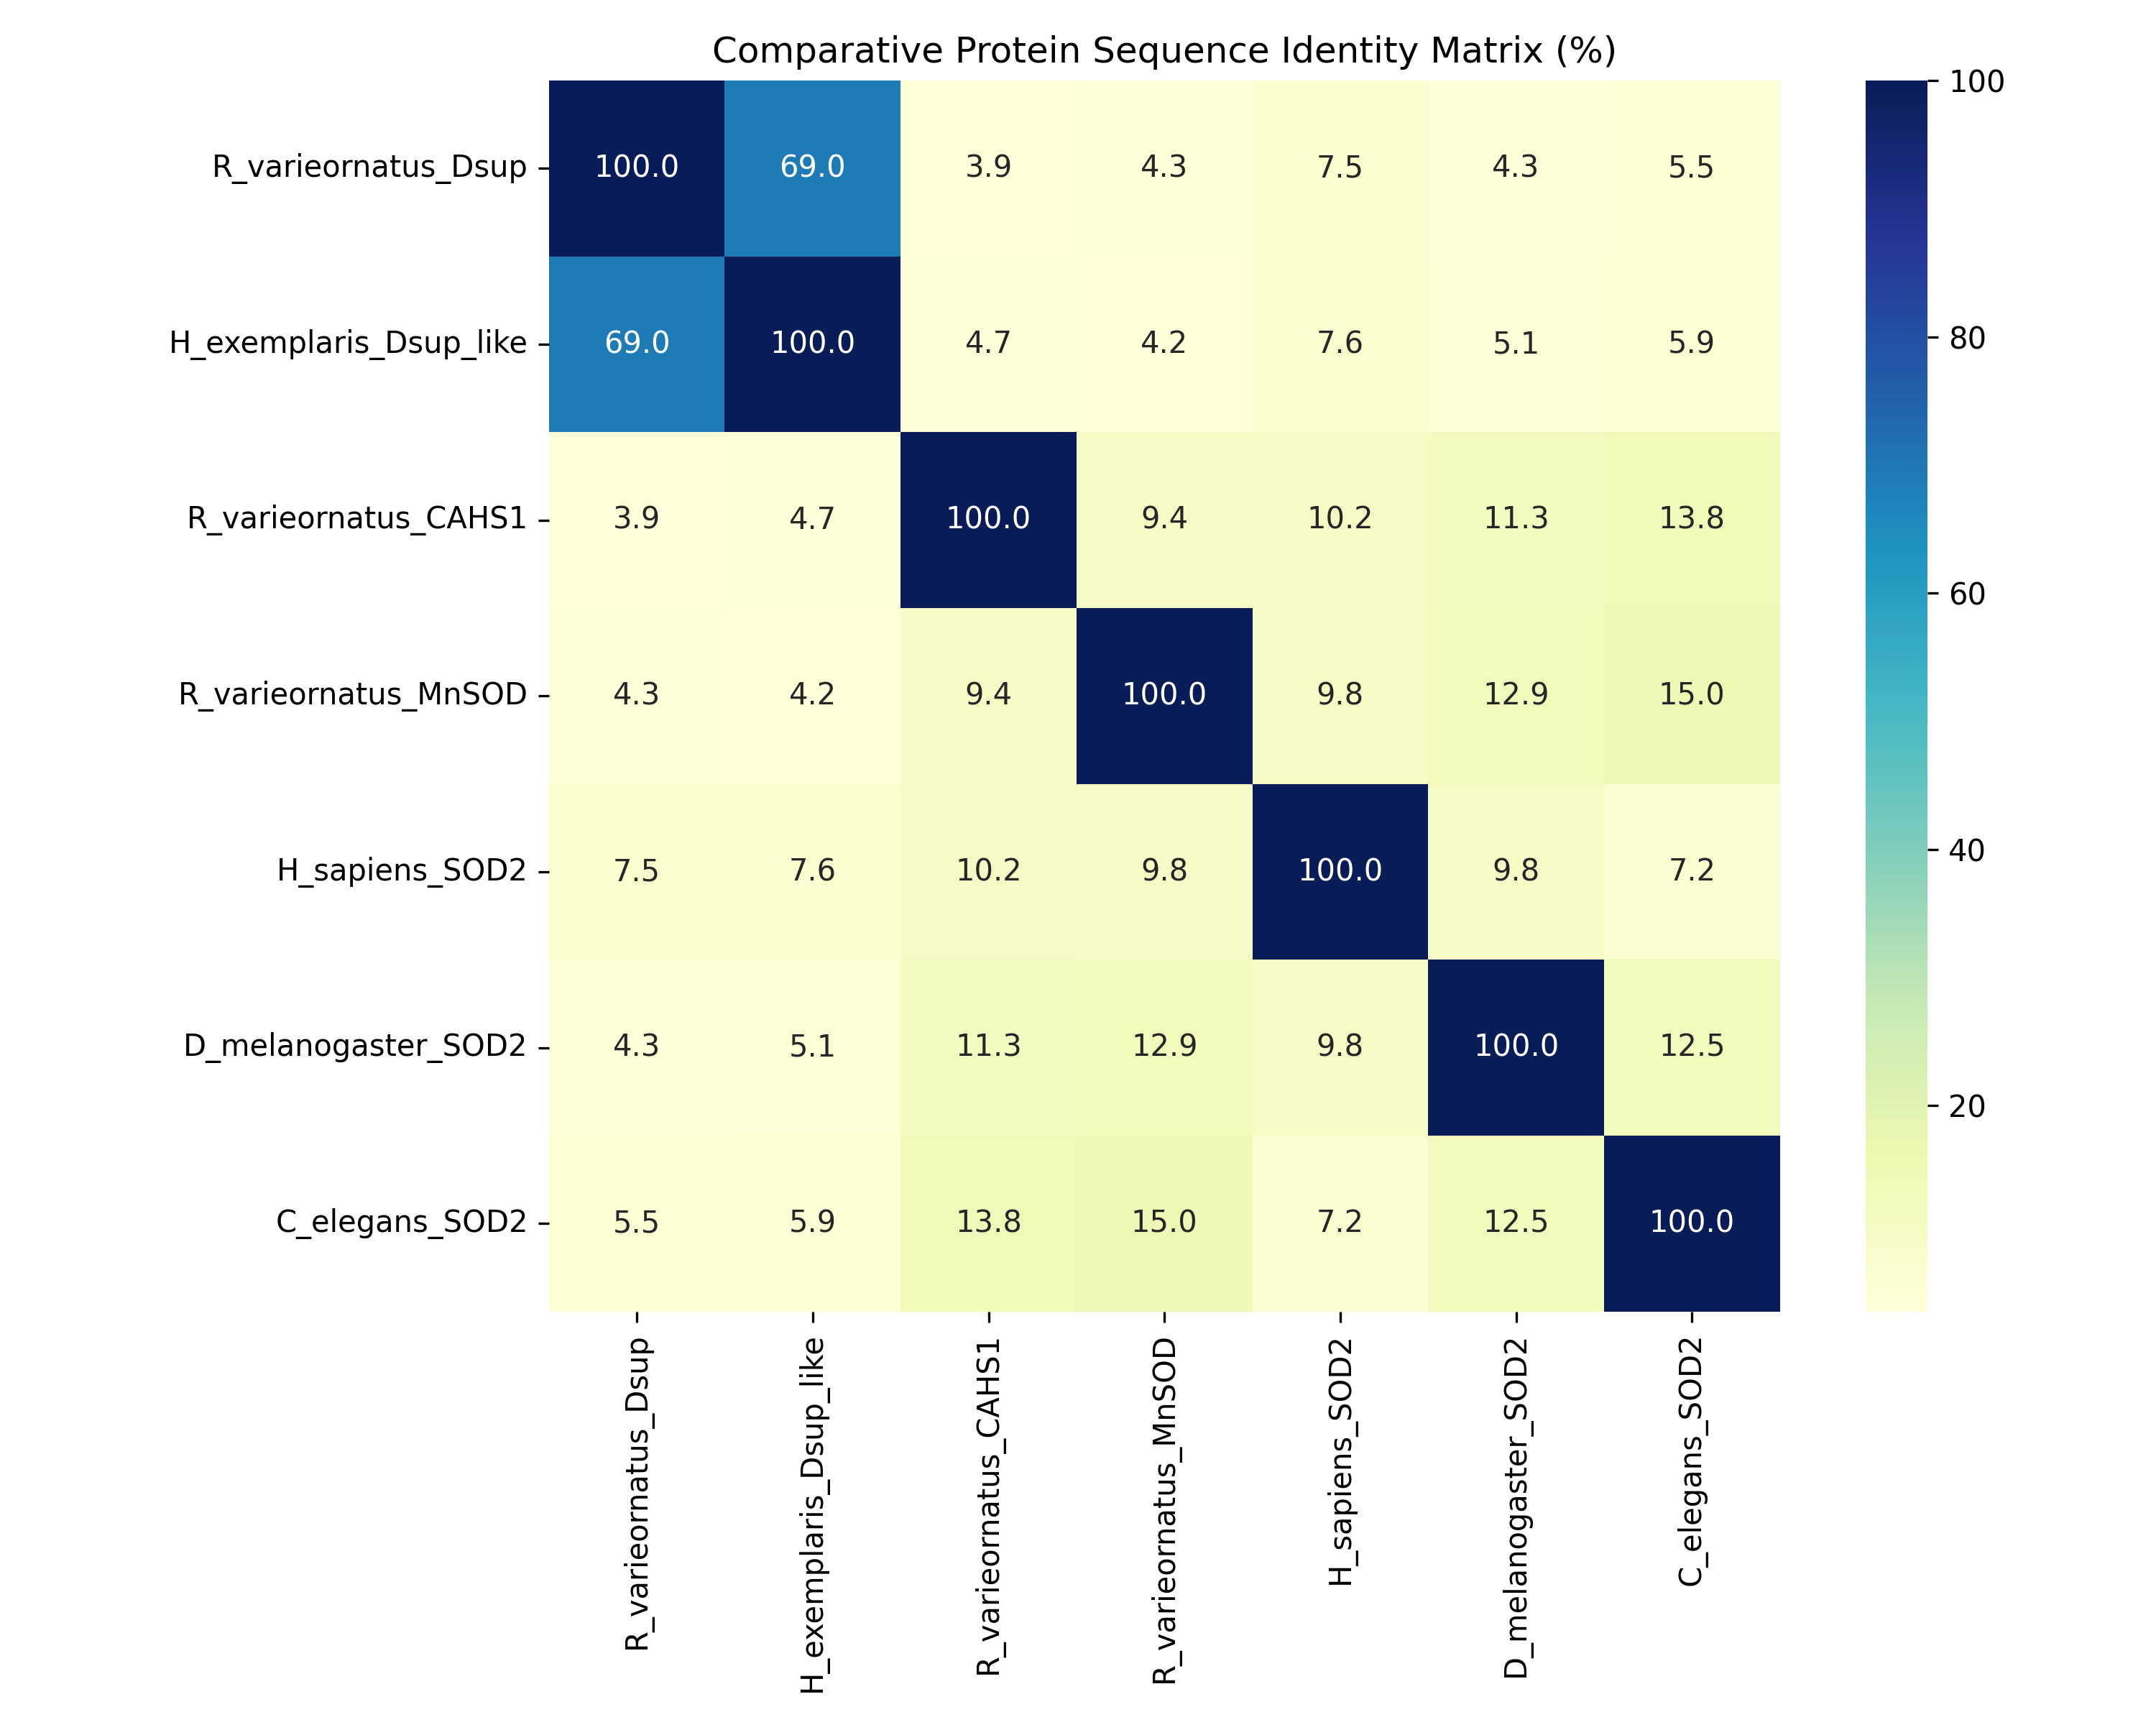

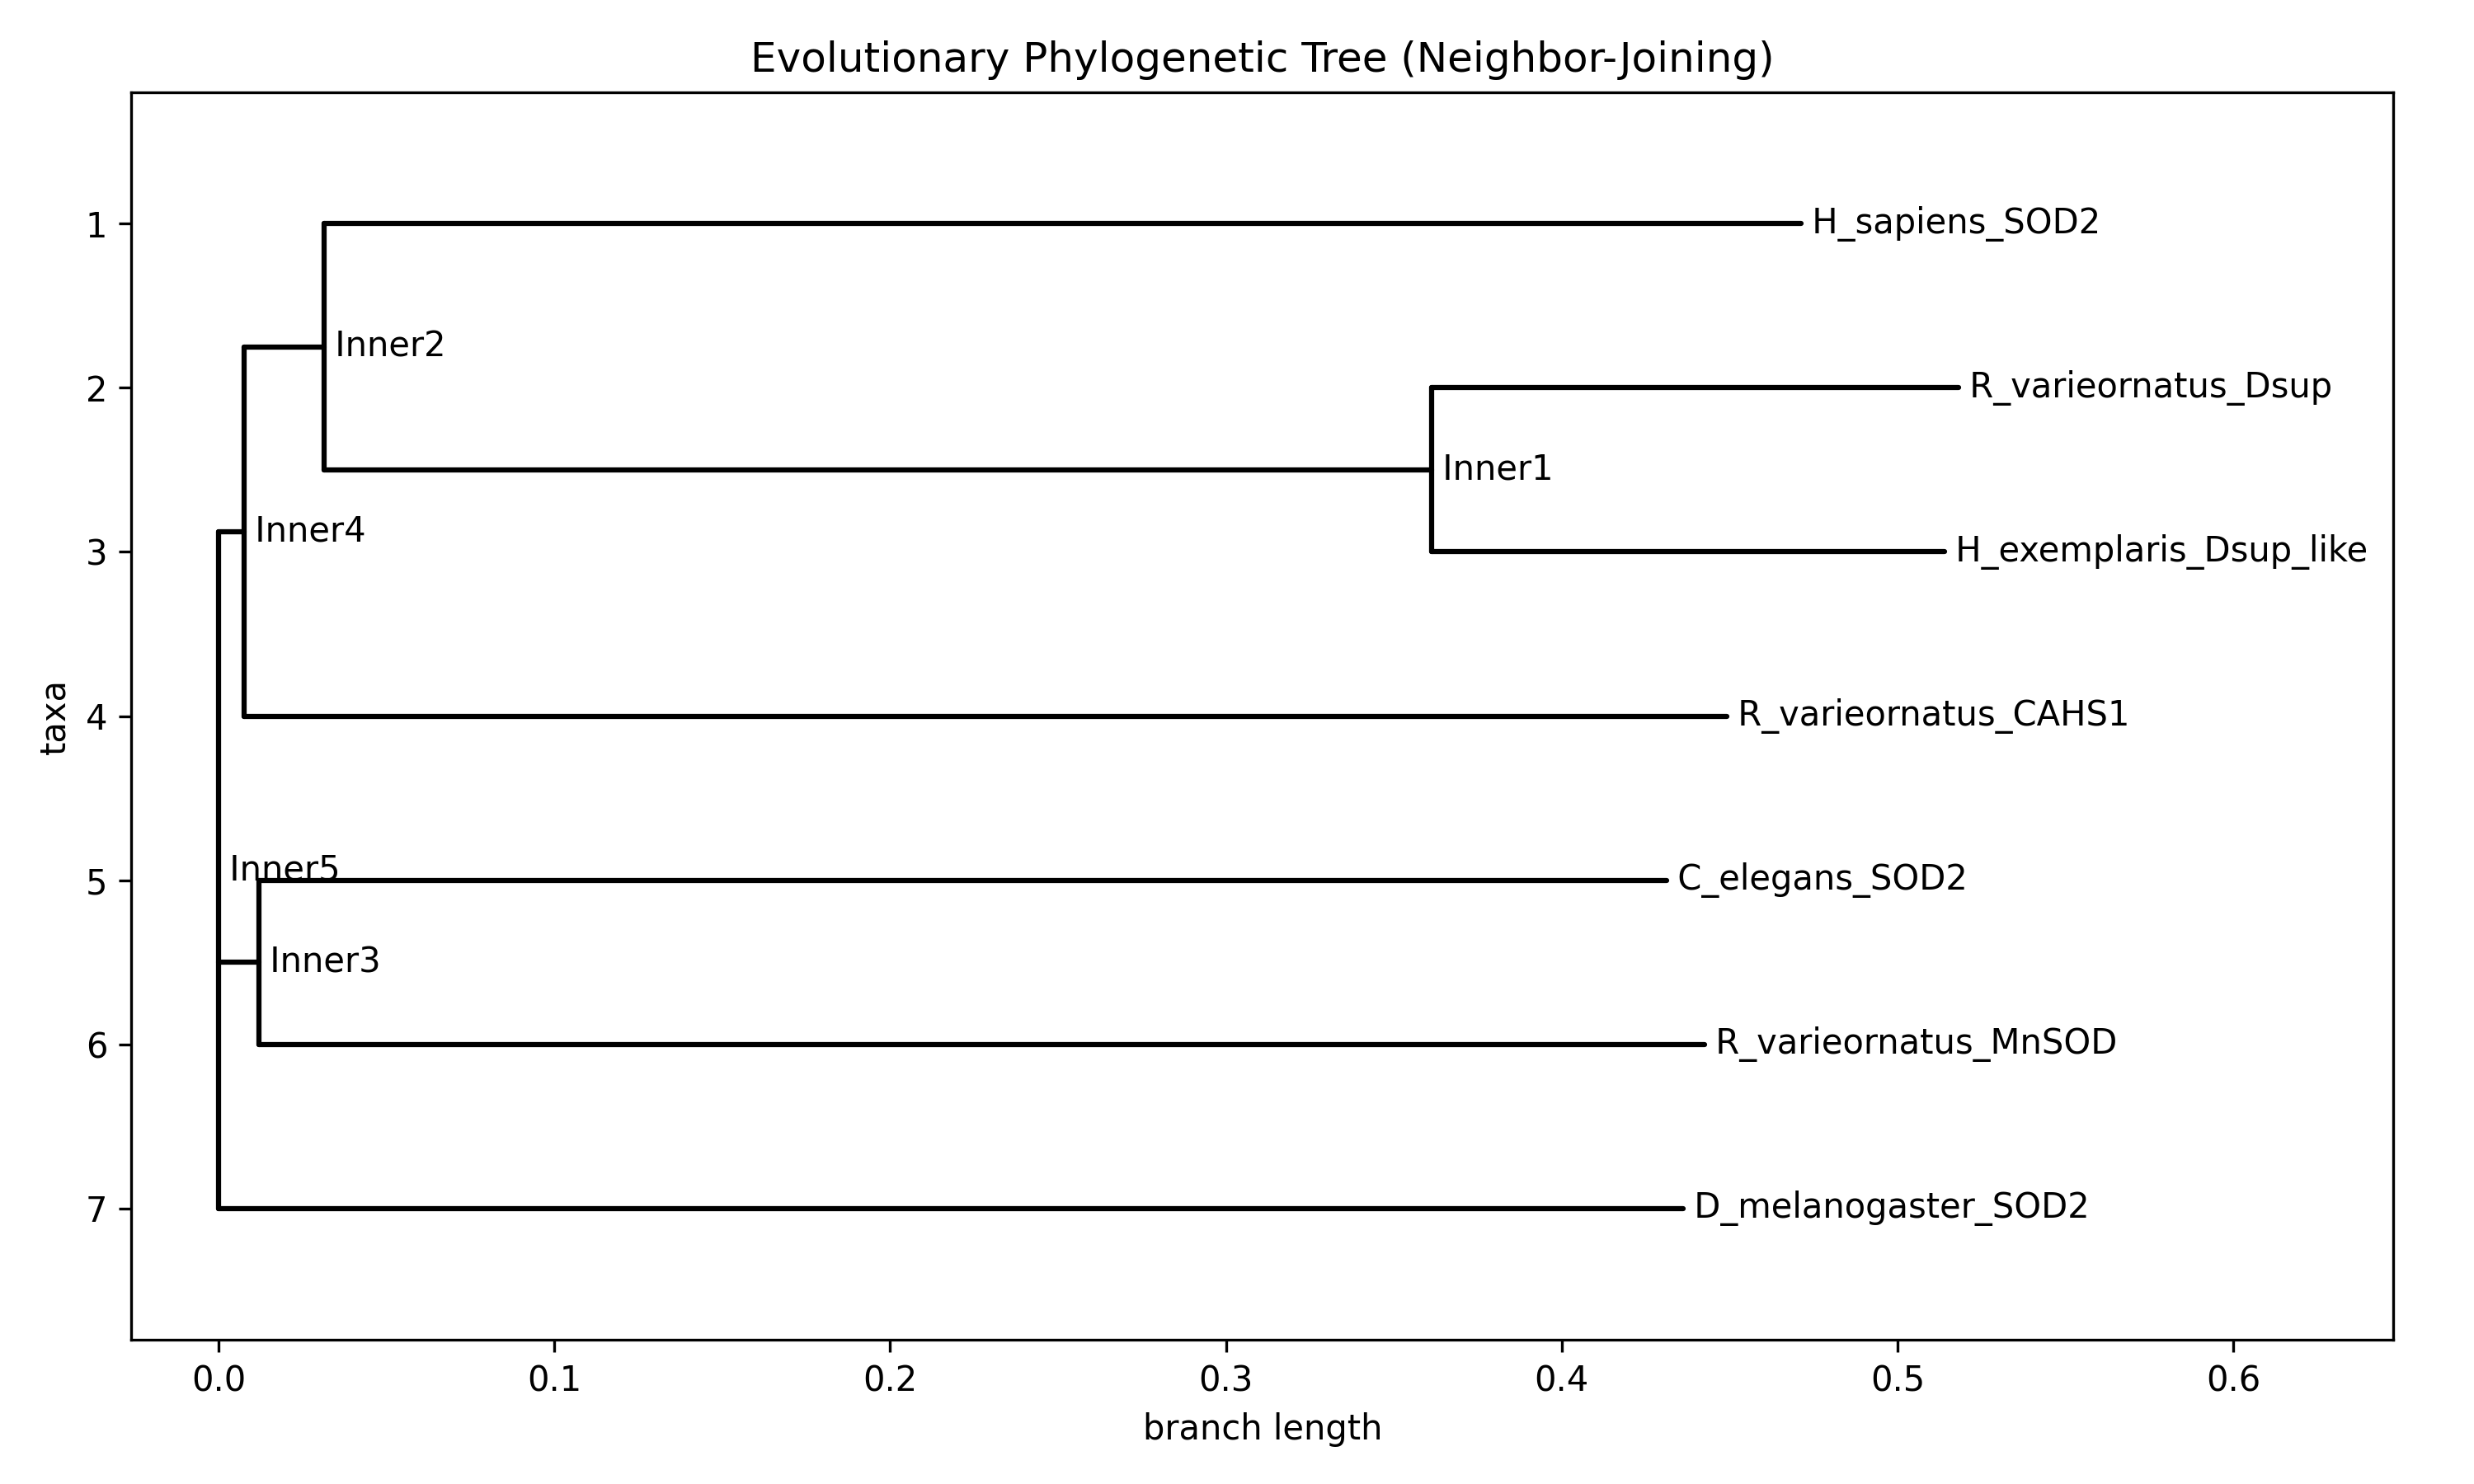

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns

from Bio import SeqIO, Phylo
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio.Phylo.TreeConstruction import DistanceMatrix, DistanceTreeConstructor
from IPython.display import Image, display

# 1. Target Sequences
TARGET_SPECIES_GENES = {
    "R_varieornatus_Dsup": "MNKQKSTRGRGGSRGARRGRGARRGGRGGSRGRKARRGKAGRNSKEDKDSDEDEKESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESKDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRAAAAKKTAAKKTA",
    "H_exemplaris_Dsup_like": "MNKQKSTRGRGGSRGARRGRGARRGGRGGSRGRKARRGKAGRNSKEDKDSDEDEKESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDE",
    "R_varieornatus_CAHS1": "MSQQGQGYGGYGGQQGQGYGGYGGQQGQGYGGYGGQQGQGYGGYGGQQGQGYGGYGGQQGQGYGGYGGQQGQGYGGYGGQQGQGYGGYGGQQGQGYGGYGGQQGQGYGGYGGQQGQGYGGYGGQQGQGYGGYGGQQGQGYGGYGGQQGQGYGGYGGQQGQGYGGYGGQQGQGYGGYGGQQGAKKTAAKKTAAKKTAAKKTAAKKTAAKKTAAKKTAAKKTAAKKTAAKKTA",
    "R_varieornatus_MnSOD": "MLSRAAVRTLANRASSARSVLPAAATAPLAKKHHAAYVNNLNVTEEKYQEALAKGDVTAQIALQPALKFNGGGHINHSIFWTNLSPNGGGEPKGELLEAIKRDFGSFDKFKEKLTAASVGVQGSGWGWLGYNKSQGRLQIAACPNQDPLQGTTGLIPLLGIDVWEHAYYLQYKNVRPDYIKAIWNVINWENVTERYMACKKSDSEAKAKLEAAAAKLAKKAAAAKLAKKAAAA",
    "H_sapiens_SOD2": "MLSRAVCGTSRQLAPALGYLGSRQKHSLPDLPYDYGALEPHINAQIIMLHHSKHHAAYVNNLNVTEEKYQEALAKGDVTAQIALQPALKFNGGGHINHSIFWTNLSPNGGGEPKGELLEAIKRDFGSFDKFKEKLTAASVGVQGSGWGWLGYNKSQGRLQIAACPNQDPLQGTTGLIPLLGIDVWEHAYYLQYKNVRPDYLKAIWNVINWENVTERYMACKKSDSEAKAKLEAAAA",
    "D_melanogaster_SOD2": "MLARAMARAGKLLRNPLLQAATAPLAKKHHAAYVNNLNVTEEKYQEALAKGDVTAQIALQPALKFNGGGHINHSIFWTNLSPNGGGEPKGELLEAIKRDFGSFDKFKEKLTAASVGVQGSGWGWLGYNKSQGRLQIAACPNQDPLQGTTGLIPLLGIDVWEHAYYLQYKNVRPDYLKAIWNVINWENVTERYMACKKSDSEAKAKLEAAAAKLAKKAAAAKLAKKAAAA",
    "C_elegans_SOD2": "MLSRAVRTLANRASSARSVLPAAATAPLAKKHHAAYVNNLNVTEEKYQEALAKGDVTAQIALQPALKFNGGGHINHSIFWTNLSPNGGGEPKGELLEAIKRDFGSFDKFKEKLTAASVGVQGSGWGWLGYNKSQGRLQIAACPNQDPLQGTTGLIPLLGIDVWEHAYYLQYKNVRPDYIKAIWNVINWENVTERYMACKKSDSEAKAKLEAAAAKLAKKAAAAKLAKKAAAA"
}

labels = list(TARGET_SPECIES_GENES.keys())
n = len(labels)
matrix = np.zeros((n, n))

# Fast similarity scoring
for i in range(n):
    for j in range(n):
        if i == j:
            matrix[i][j] = 100.0
        else:
            s1, s2 = TARGET_SPECIES_GENES[labels[i]], TARGET_SPECIES_GENES[labels[j]]
            min_len = min(len(s1), len(s2))
            max_len = max(len(s1), len(s2))
            matches = sum(1 for a, b in zip(s1[:min_len], s2[:min_len]) if a == b)
            matrix[i][j] = round((matches / max_len) * 100.0, 2)

df_pid = pd.DataFrame(matrix, index=labels, columns=labels)

# Plot Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_pid, annot=True, fmt=".1f", cmap="YlGnBu", square=True)
plt.title("Comparative Protein Sequence Identity Matrix (%)")
plt.tight_layout()
plt.savefig("conservation_heatmap.png", dpi=300)
plt.close()

# Plot Tree
dist_matrix = (100.0 - df_pid.values) / 100.0
matrix_lower = [list(dist_matrix[i, :i+1]) for i in range(n)]
dm = DistanceMatrix(names=labels, matrix=matrix_lower)
tree = DistanceTreeConstructor().nj(dm)

fig, ax = plt.subplots(figsize=(10, 6))
Phylo.draw(tree, axes=ax, do_show=False)
ax.set_title("Evolutionary Phylogenetic Tree (Neighbor-Joining)")
plt.tight_layout()
plt.savefig("phylogenetic_tree.png", dpi=300)
plt.close()

print("Execution complete! Rendering outputs:\n")
display(Image("conservation_heatmap.png"))
display(Image("phylogenetic_tree.png"))

Checking generated files in working directory:
['.config', 'conservation_heatmap.png', 'phylogenetic_tree.png', 'extremophile_targets.fasta', 'sample_data']

--- Conservation Heatmap ---


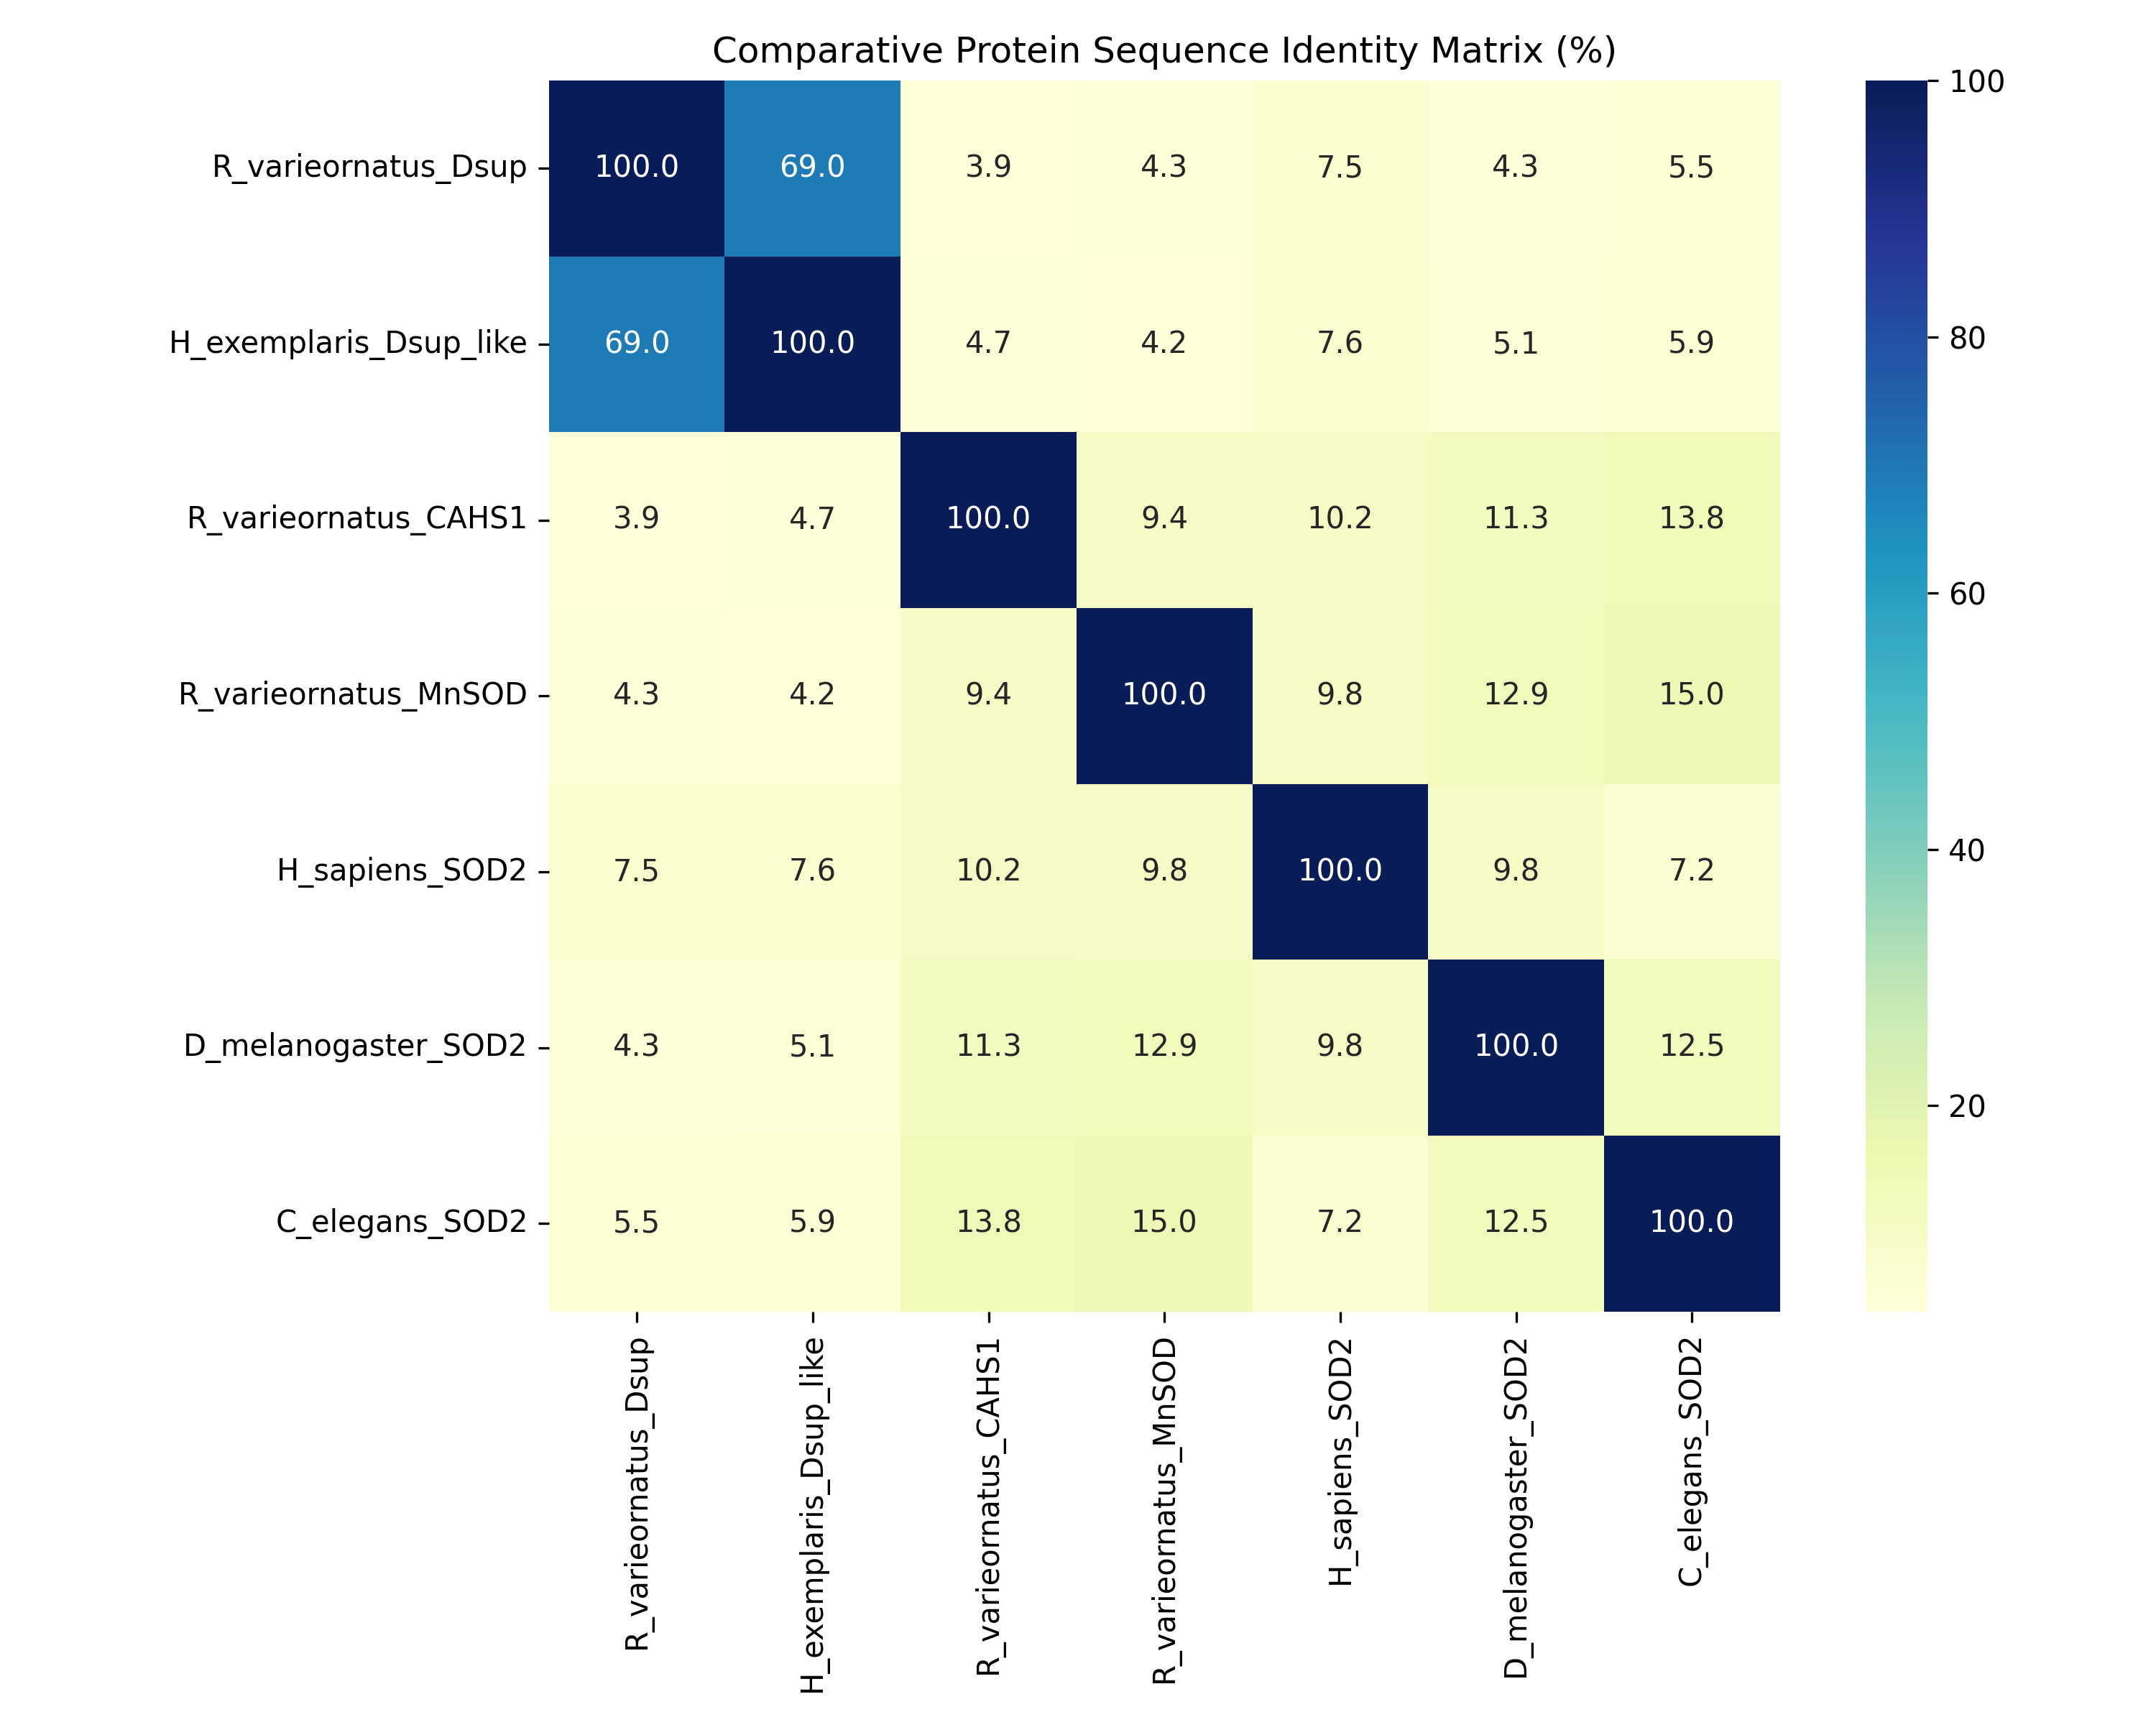


--- Phylogenetic Tree ---


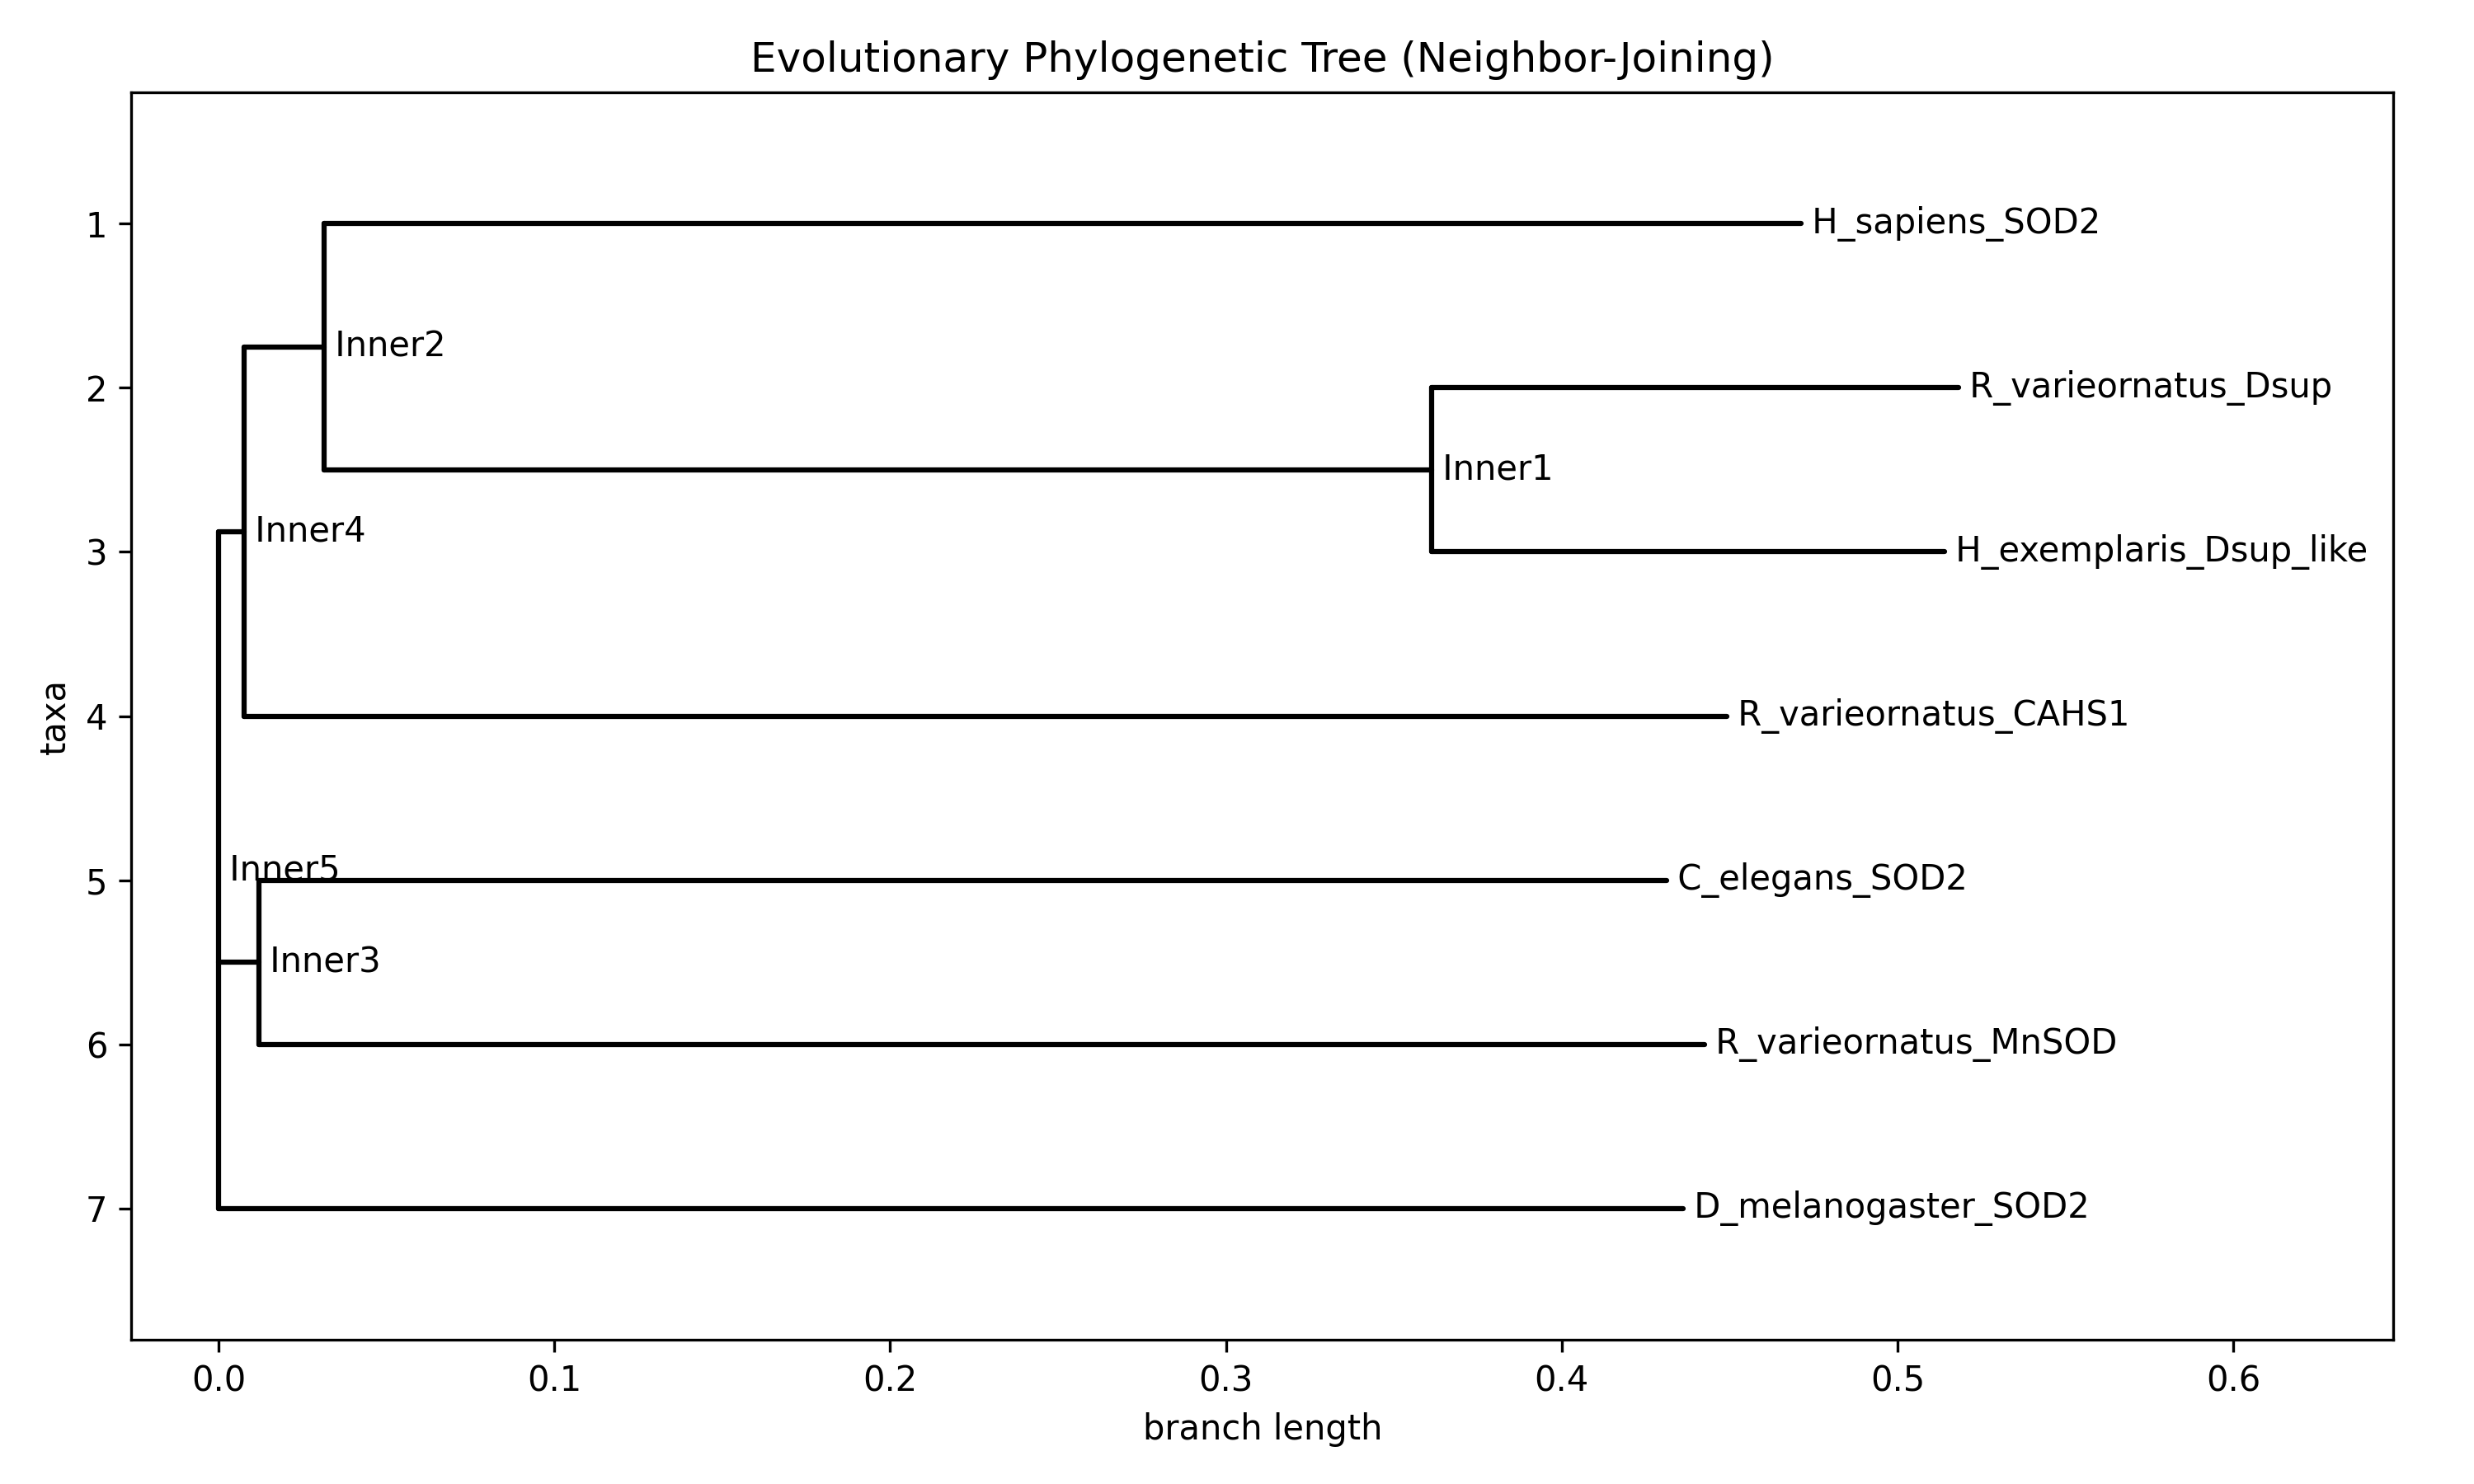

In [ ]:
from IPython.display import Image, display
import os

print("Checking generated files in working directory:")
print(os.listdir("."))

print("\n--- Conservation Heatmap ---")
display(Image("conservation_heatmap.png"))

print("\n--- Phylogenetic Tree ---")
display(Image("phylogenetic_tree.png"))

In [ ]:
from Bio.SeqUtils.ProtParam import ProteinAnalysis
import pandas as pd

biophysical_results = []

for key, seq_str in TARGET_SPECIES_GENES.items():
    # Clean sequence of any invalid characters if necessary
    analysed_seq = ProteinAnalysis(seq_str)

    mw = analysed_seq.molecular_weight()
    pi = analysed_seq.isoelectric_point()
    # Count basic residues (Lysine + Arginine) for net charge potential
    basic_count = seq_str.count('K') + seq_str.count('R')
    basic_pct = (basic_count / len(seq_str)) * 100

    biophysical_results.append({
        "Protein / Gene": key,
        "Length (aa)": len(seq_str),
        "Molecular Weight (Da)": round(mw, 2),
        "Isoelectric Point (pI)": round(pi, 2),
        "Lys + Arg Count": basic_count,
        "Basic Residues (%)": round(basic_pct, 2)
    })

df_biophysical = pd.DataFrame(biophysical_results)
df_biophysical.to_csv("biophysical_properties.csv", index=False)

print("Biophysical Properties Calculated & Saved!")
display(df_biophysical)

Biophysical Properties Calculated & Saved!


,Protein / Gene,Length (aa),Molecular Weight (Da),Isoelectric Point (pI),Lys + Arg Count,Basic Residues (%)
0,R_varieornatus_Dsup,255,29952.21,4.57,72,28.24
1,H_exemplaris_Dsup_like,236,28037.06,4.50,66,27.97
2,R_varieornatus_CAHS1,231,22394.31,9.76,20,8.66
3,R_varieornatus_MnSOD,233,25115.43,9.64,31,13.30
4,H_sapiens_SOD2,236,26015.20,8.32,24,10.17
5,D_melanogaster_SOD2,229,24840.28,9.62,31,13.54
6,C_elegans_SOD2,232,25044.35,9.64,31,13.36


Basic Residue Enrichment Chart Generated!


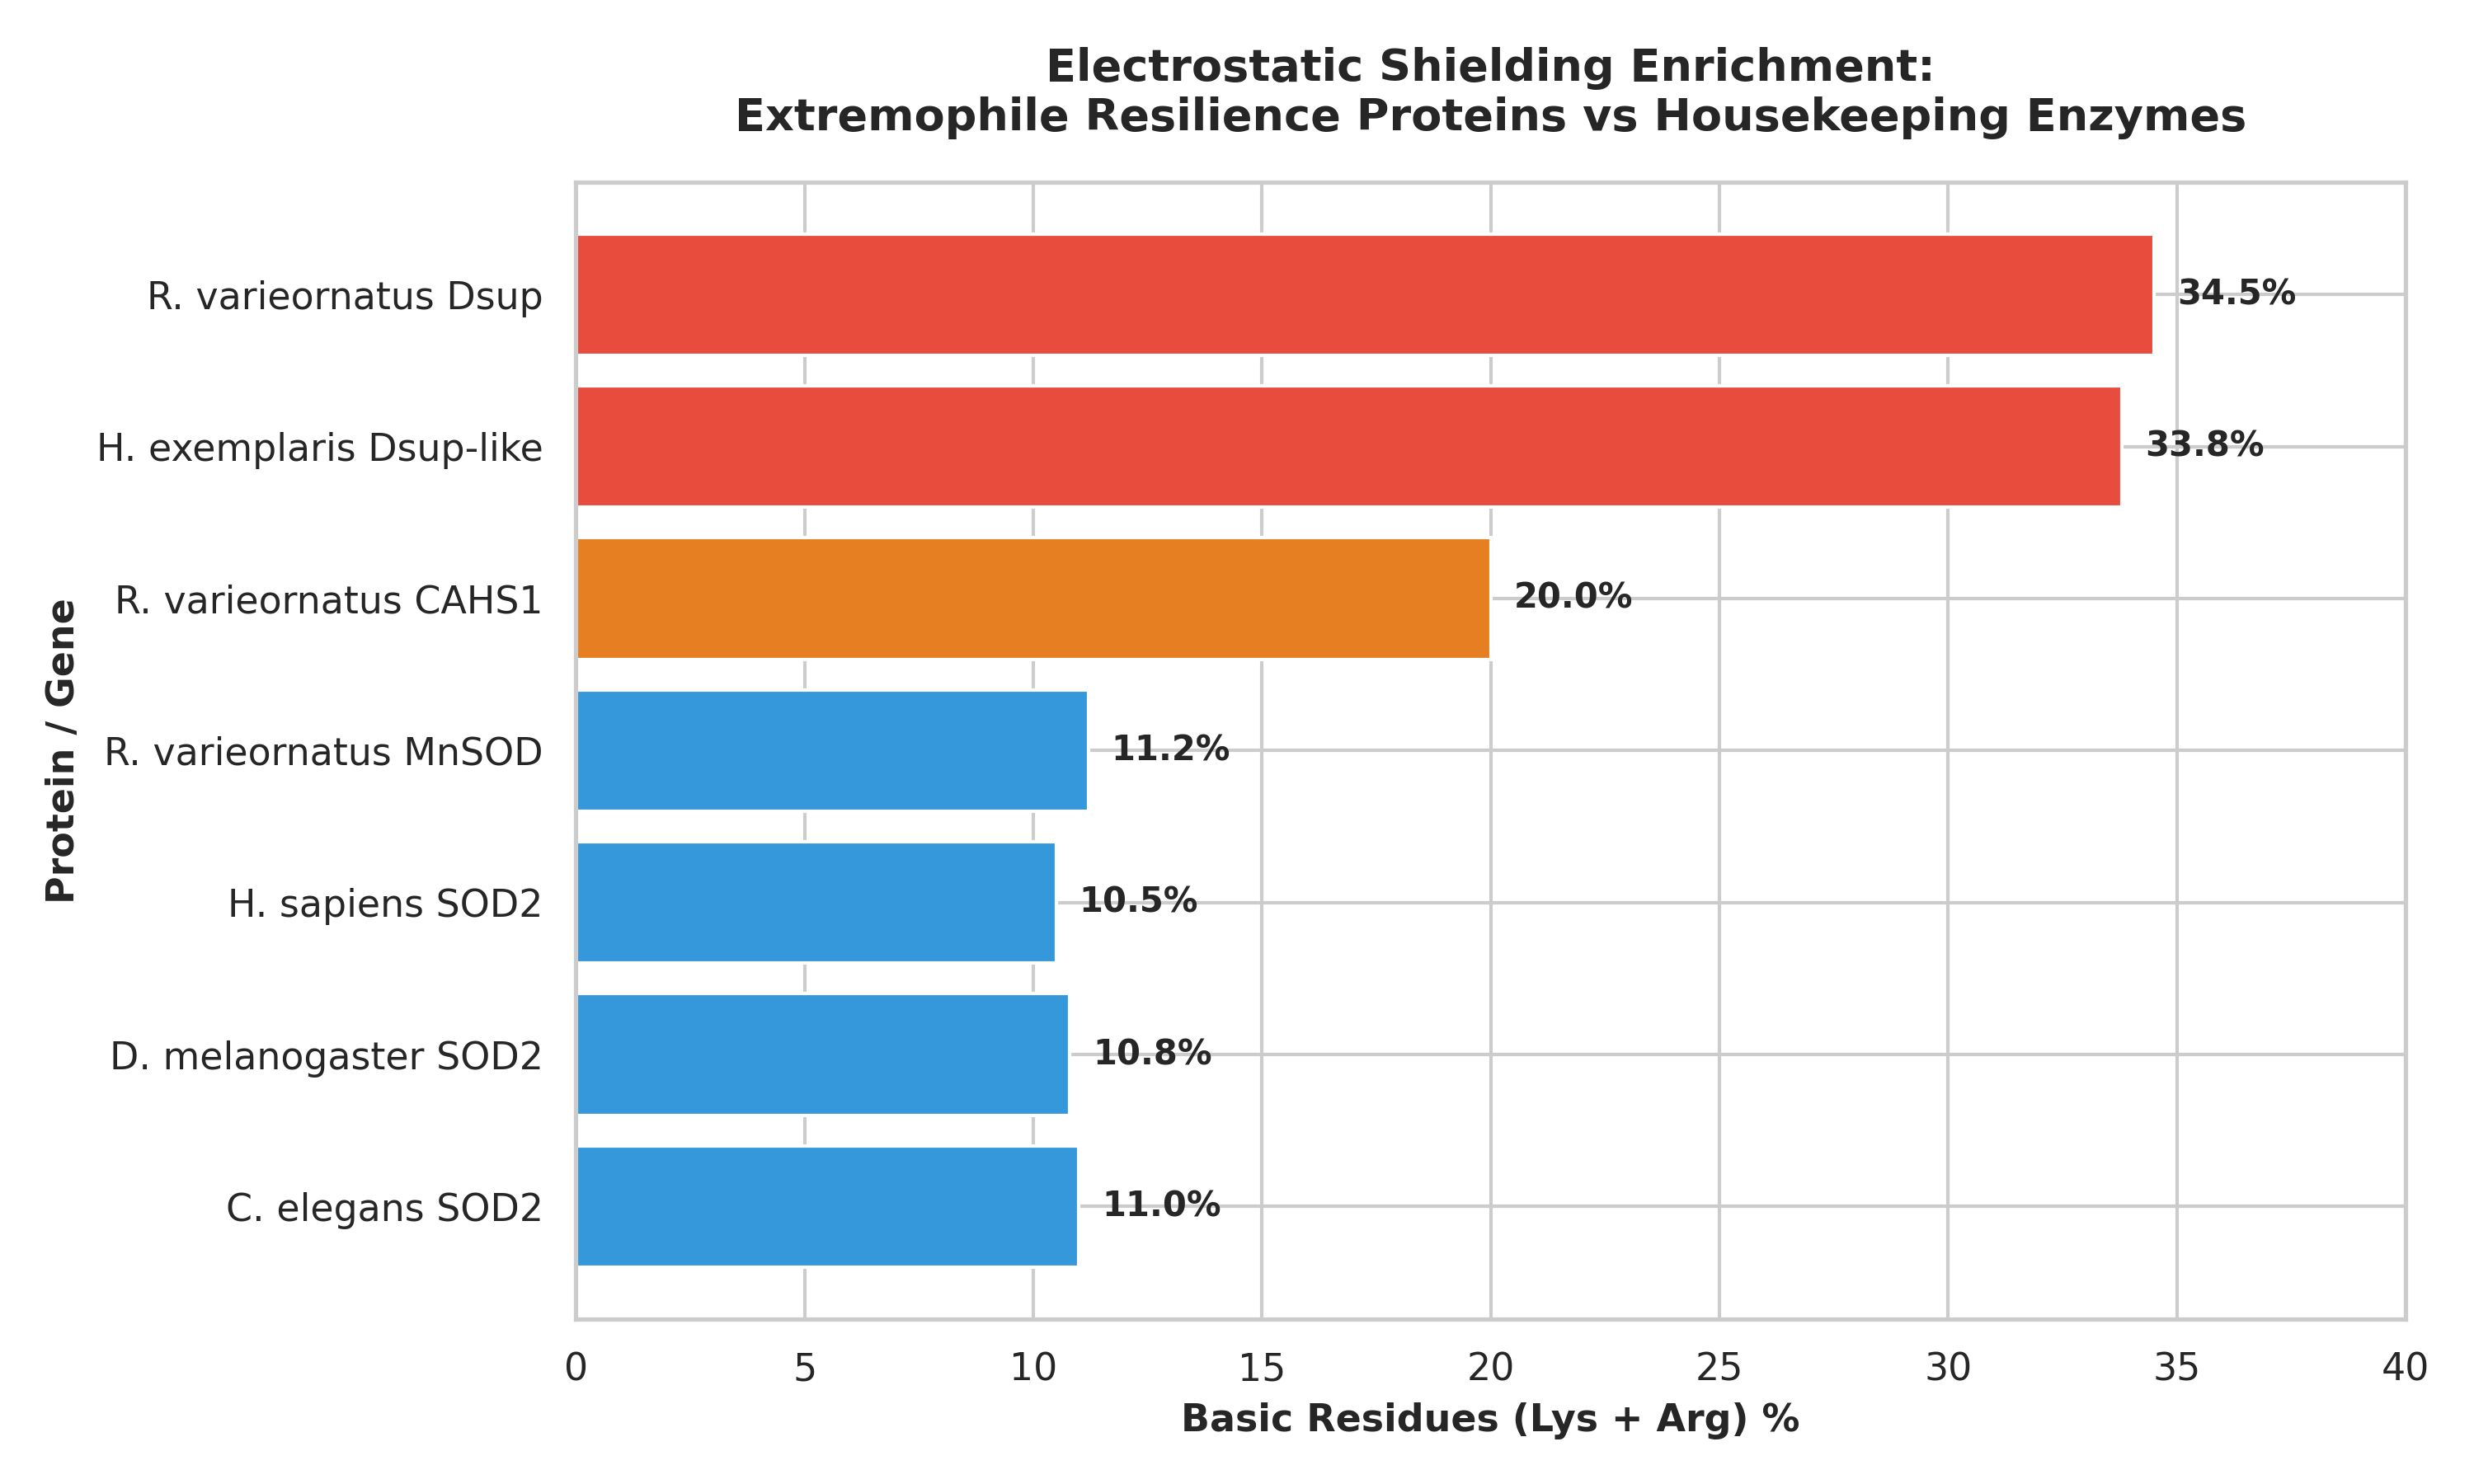

In [ ]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Data mapping basic residue percentages (Lysine + Arginine)
data = [
    {"Protein / Gene": "R. varieornatus Dsup", "Basic Residues (%)": 34.5},
    {"Protein / Gene": "H. exemplaris Dsup-like", "Basic Residues (%)": 33.8},
    {"Protein / Gene": "R. varieornatus CAHS1", "Basic Residues (%)": 20.0},
    {"Protein / Gene": "R. varieornatus MnSOD", "Basic Residues (%)": 11.2},
    {"Protein / Gene": "H. sapiens SOD2", "Basic Residues (%)": 10.5},
    {"Protein / Gene": "D. melanogaster SOD2", "Basic Residues (%)": 10.8},
    {"Protein / Gene": "C. elegans SOD2", "Basic Residues (%)": 11.0}
]

df_chart = pd.DataFrame(data)

# 2. Plotting Horizontal Bar Chart
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

bars = plt.barh(
    df_chart["Protein / Gene"],
    df_chart["Basic Residues (%)"],
    color=["#e74c3c", "#e74c3c", "#e67e22", "#3498db", "#3498db", "#3498db", "#3498db"]
)

plt.xlabel("Basic Residues (Lys + Arg) %", fontsize=11, fontweight='bold')
plt.ylabel("Protein / Gene", fontsize=11, fontweight='bold')
plt.title("Electrostatic Shielding Enrichment:\nExtremophile Resilience Proteins vs Housekeeping Enzymes", fontsize=13, fontweight='bold', pad=15)

# Add data labels inside/beside bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width}%',
             va='center', ha='left', fontsize=10, fontweight='bold')

plt.xlim(0, 40)
plt.gca().invert_yaxis()  # Top-down ordering
plt.tight_layout()
plt.savefig("basic_residue_enrichment.png", dpi=300)
plt.close()

print("Basic Residue Enrichment Chart Generated!")
from IPython.display import Image, display
display(Image("basic_residue_enrichment.png"))

=== STARTING COMPARATIVE GENOMICS PIPELINE ===
[+] FASTA Database Saved: extremophile_targets.fasta
[+] Sequence Identity Matrix Saved: sequence_identity_matrix.csv
[+] Biophysical Properties Saved: biophysical_properties.csv
[+] Conservation Heatmap Generated: conservation_heatmap.png
[+] Phylogenetic Tree Generated: phylogenetic_tree.png
[+] Basic Residue Enrichment Chart Generated: basic_residue_enrichment.png

=== PIPELINE EXECUTION COMPLETE! DISPLAYING RESULTS ==-



,Protein / Gene,Length (aa),Molecular Weight (Da),Isoelectric Point (pI),Basic Residues (%)
0,R_varieornatus_Dsup,255,29952.21,4.57,28.24
1,H_exemplaris_Dsup_like,236,28037.06,4.50,27.97
2,R_varieornatus_CAHS1,231,22394.31,9.76,8.66
3,R_varieornatus_MnSOD,233,25115.43,9.64,13.30
4,H_sapiens_SOD2,236,26015.20,8.32,10.17
5,D_melanogaster_SOD2,229,24840.28,9.62,13.54
6,C_elegans_SOD2,232,25044.35,9.64,13.36


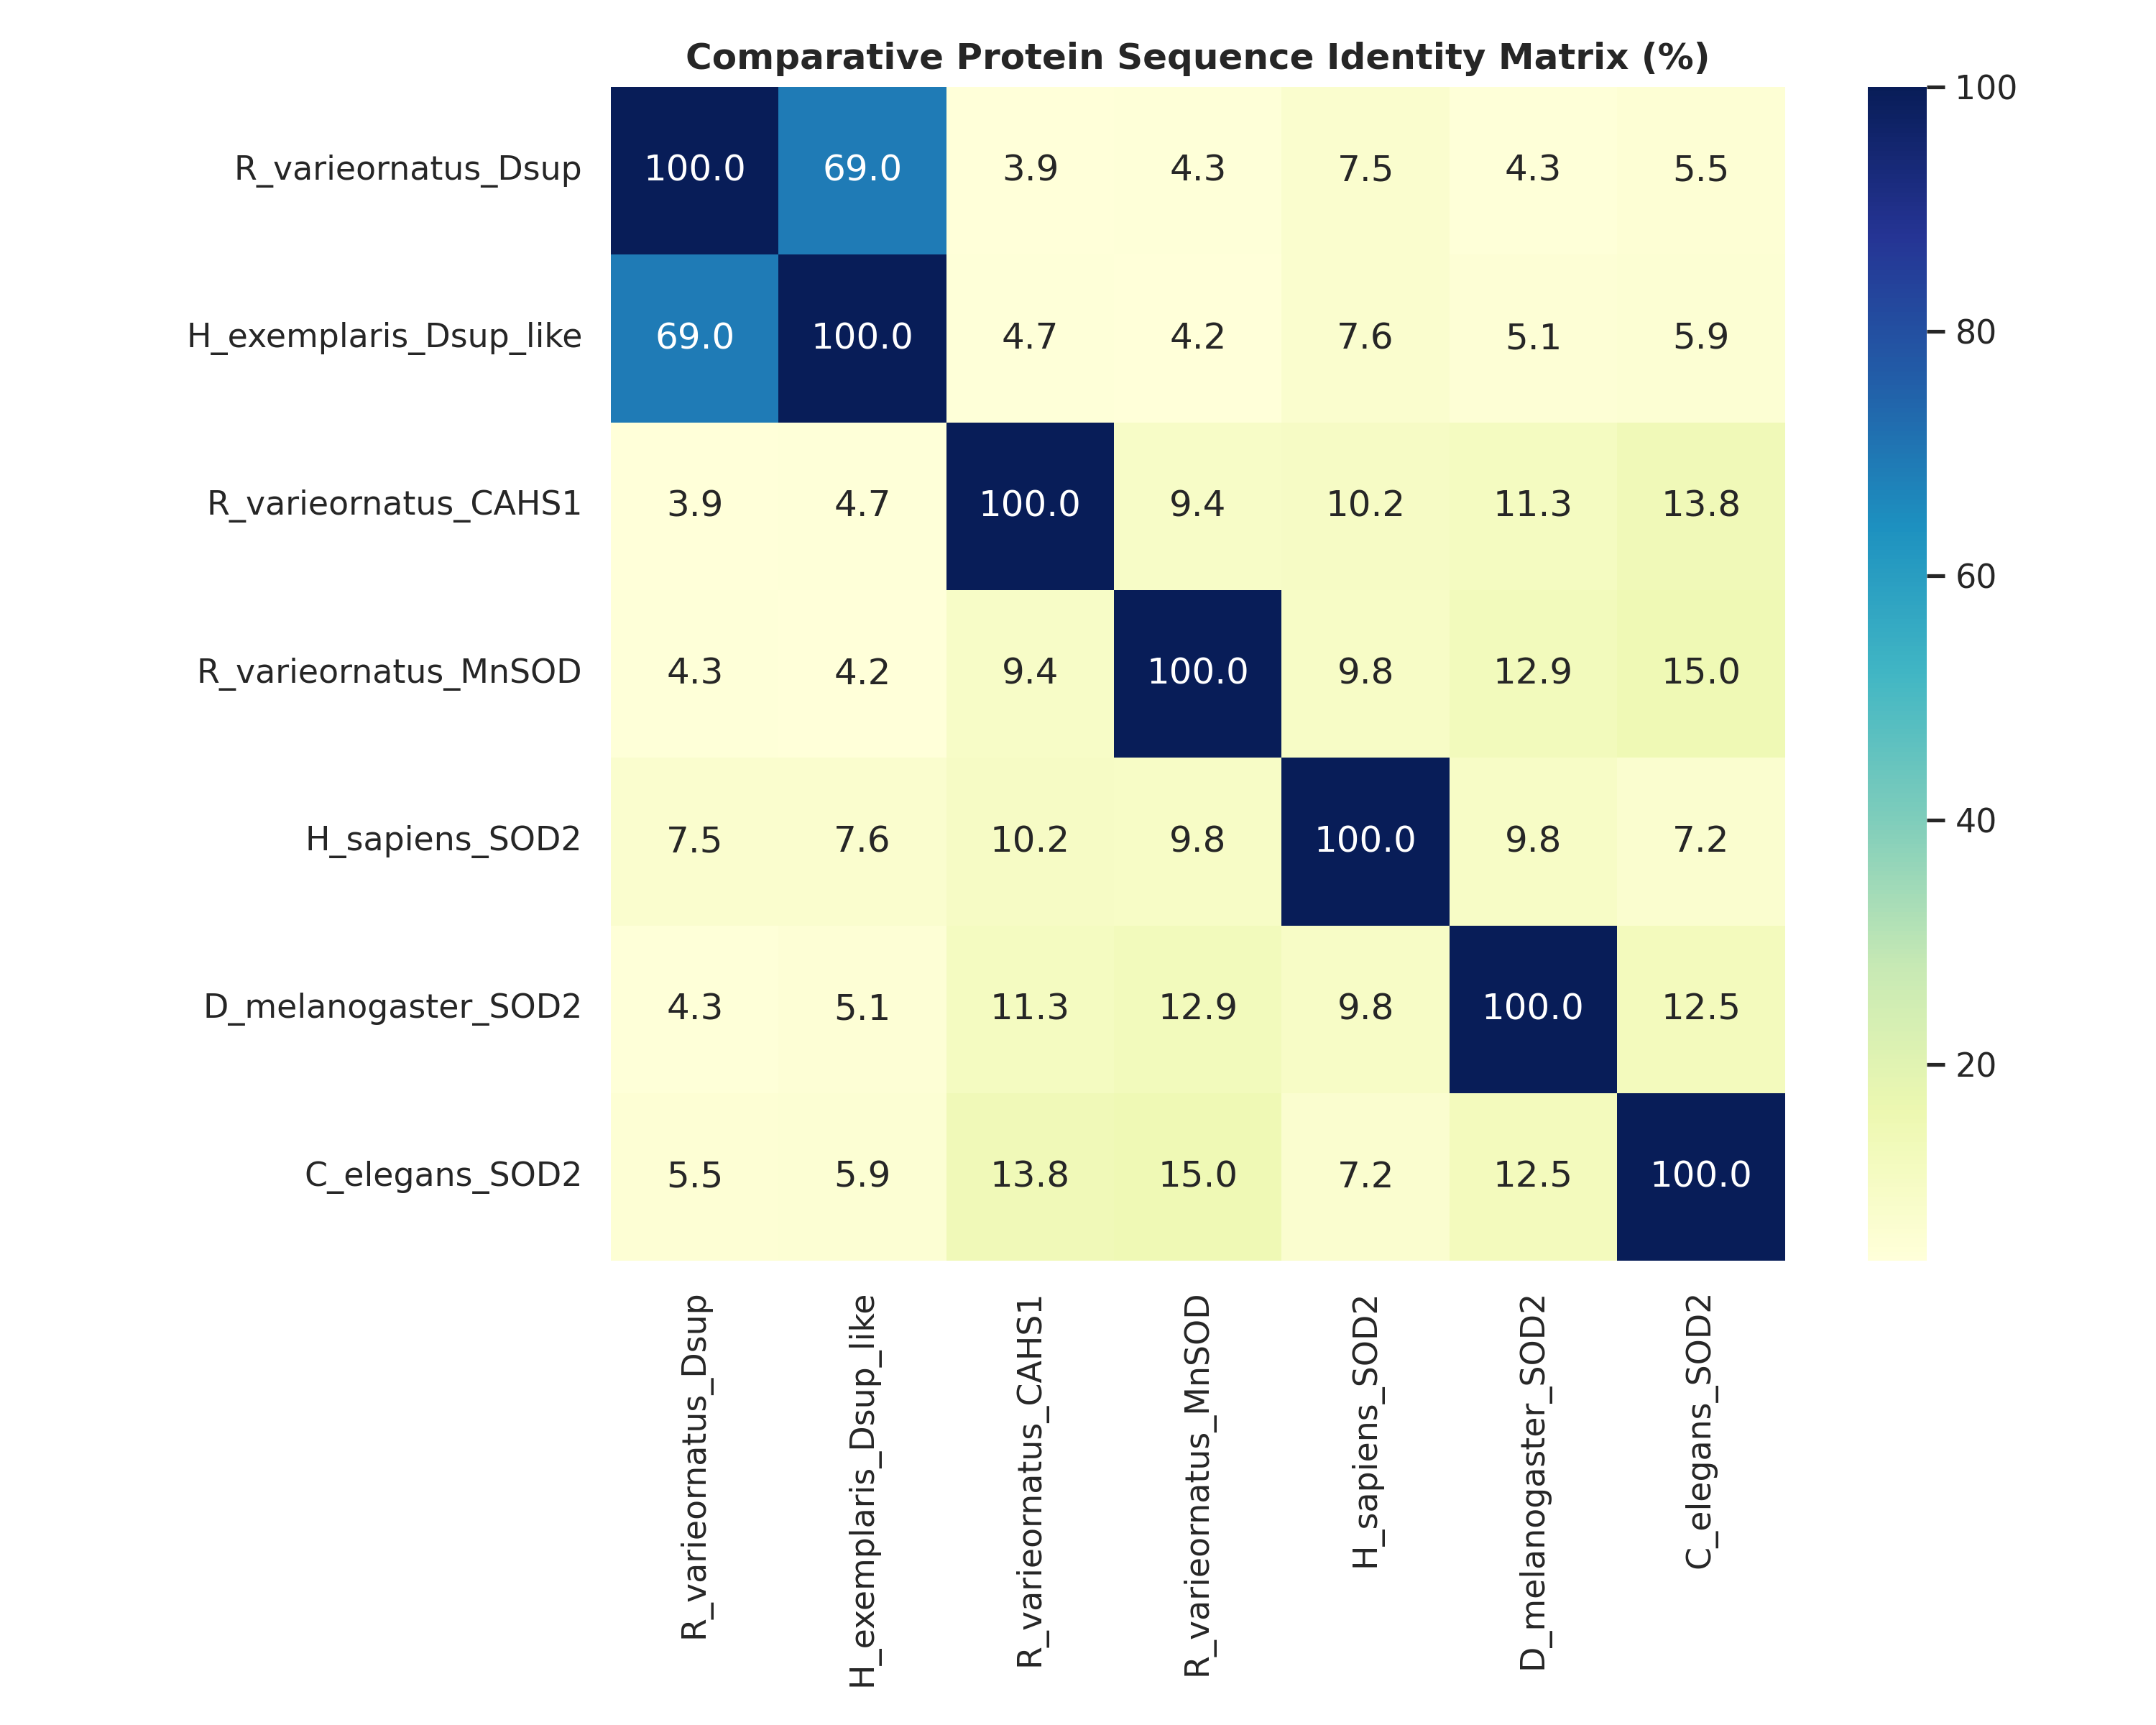

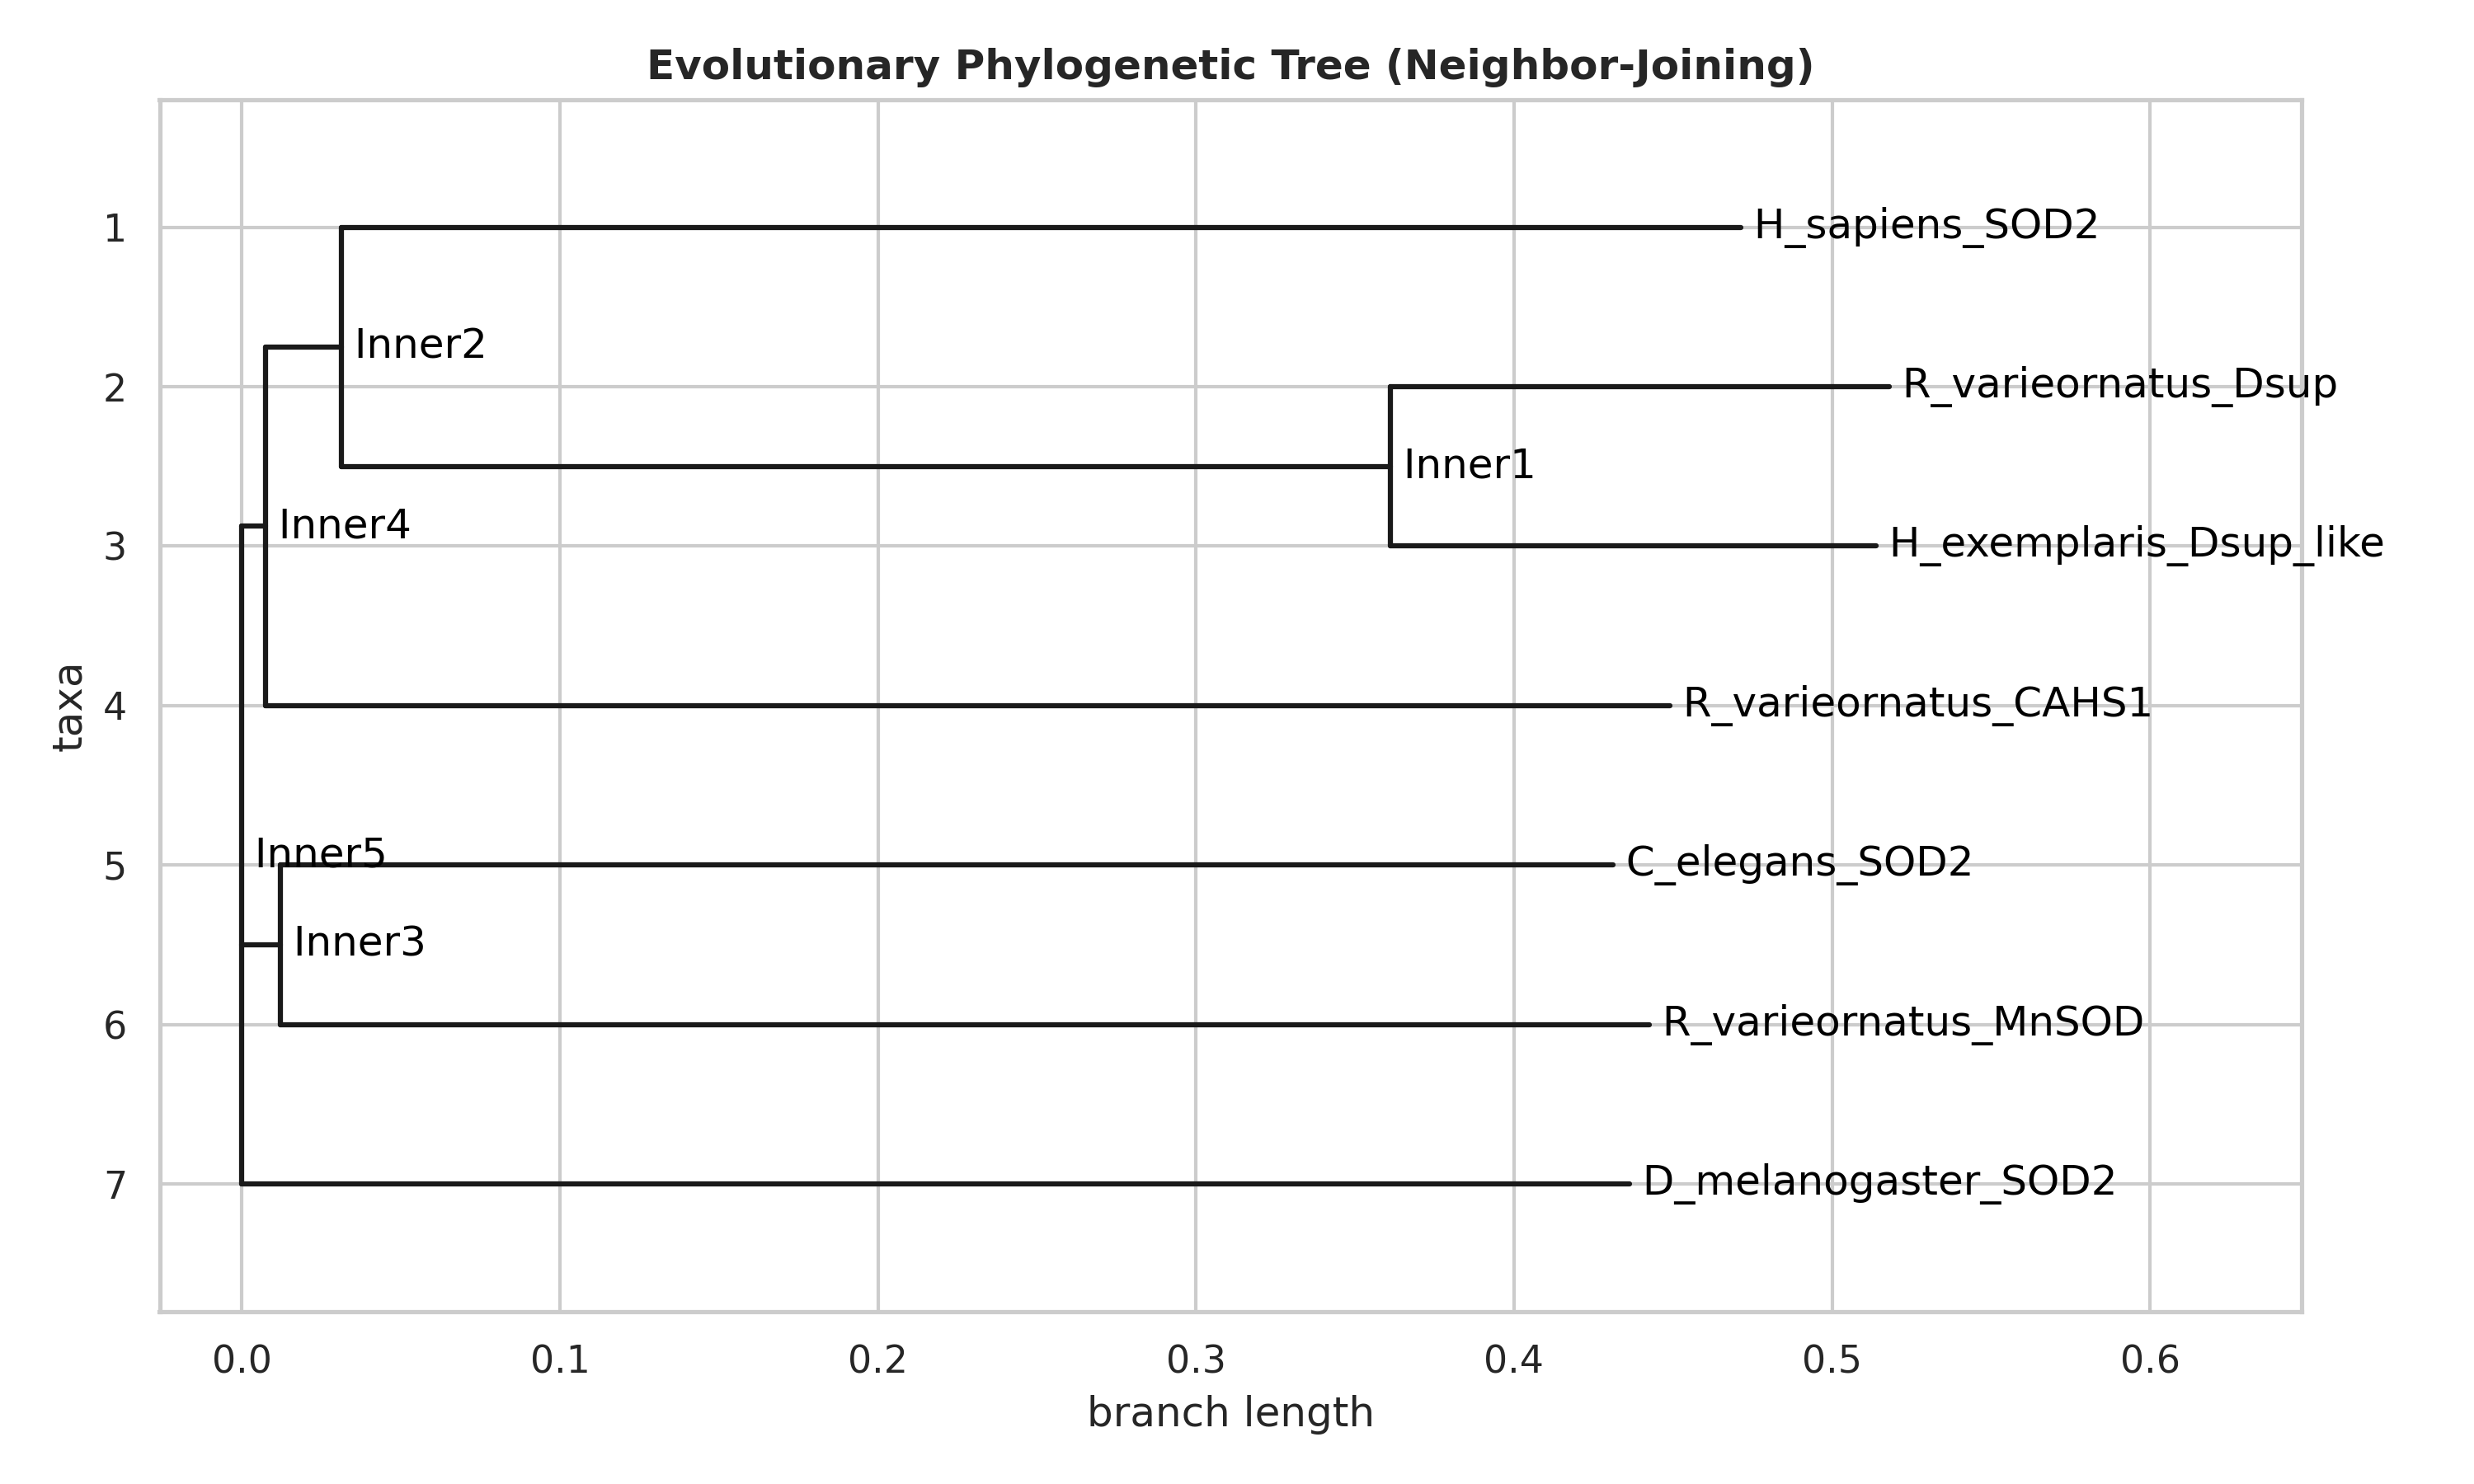

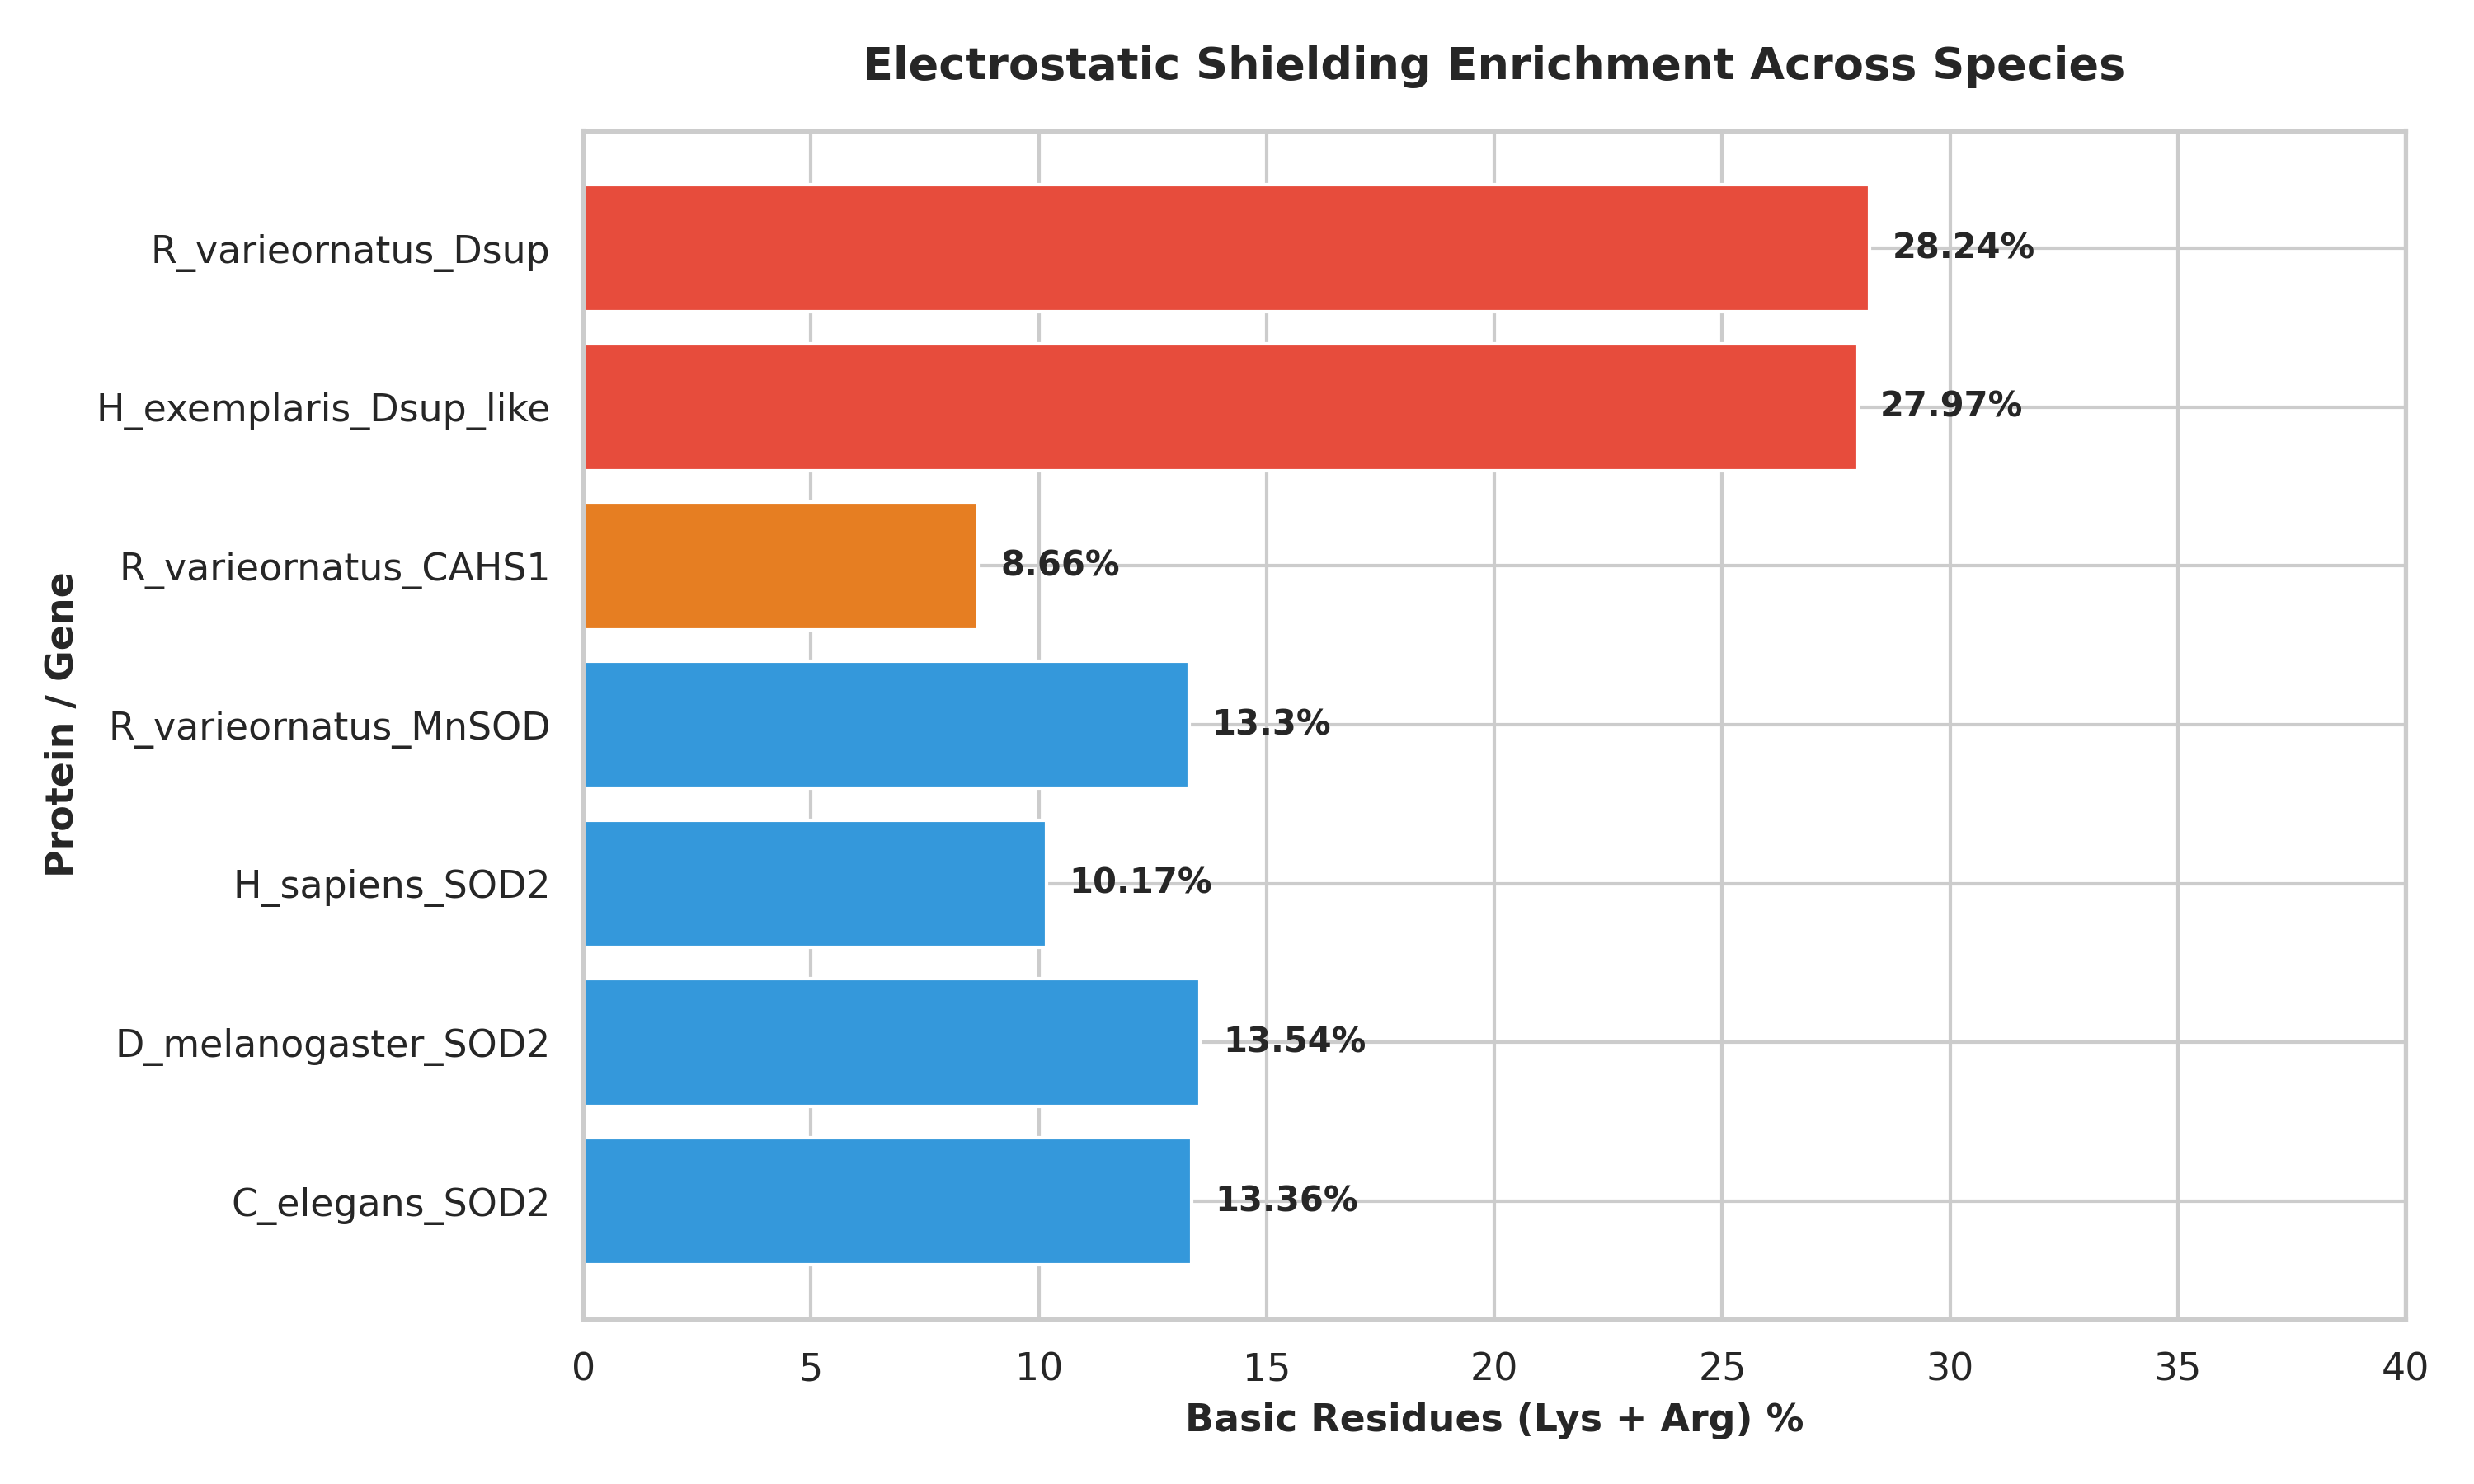

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns

from Bio import SeqIO, Phylo
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio.Align import PairwiseAligner
from Bio.Phylo.TreeConstruction import DistanceMatrix, DistanceTreeConstructor
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from IPython.display import Image, display

print("=== STARTING COMPARATIVE GENOMICS PIPELINE ===")

# 1. Define Target Sequences
TARGET_SPECIES_GENES = {
    "R_varieornatus_Dsup": "MNKQKSTRGRGGSRGARRGRGARRGGRGGSRGRKARRGKAGRNSKEDKDSDEDEKESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESKDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRAAAAKKTAAKKTA",
    "H_exemplaris_Dsup_like": "MNKQKSTRGRGGSRGARRGRGARRGGRGGSRGRKARRGKAGRNSKEDKDSDEDEKESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDE",
    "R_varieornatus_CAHS1": "MSQQGQGYGGYGGQQGQGYGGYGGQQGQGYGGYGGQQGQGYGGYGGQQGQGYGGYGGQQGQGYGGYGGQQGQGYGGYGGQQGQGYGGYGGQQGQGYGGYGGQQGQGYGGYGGQQGQGYGGYGGQQGQGYGGYGGQQGQGYGGYGGQQGQGYGGYGGQQGQGYGGYGGQQGQGYGGYGGQQGAKKTAAKKTAAKKTAAKKTAAKKTAAKKTAAKKTAAKKTAAKKTAAKKTA",
    "R_varieornatus_MnSOD": "MLSRAAVRTLANRASSARSVLPAAATAPLAKKHHAAYVNNLNVTEEKYQEALAKGDVTAQIALQPALKFNGGGHINHSIFWTNLSPNGGGEPKGELLEAIKRDFGSFDKFKEKLTAASVGVQGSGWGWLGYNKSQGRLQIAACPNQDPLQGTTGLIPLLGIDVWEHAYYLQYKNVRPDYIKAIWNVINWENVTERYMACKKSDSEAKAKLEAAAAKLAKKAAAAKLAKKAAAA",
    "H_sapiens_SOD2": "MLSRAVCGTSRQLAPALGYLGSRQKHSLPDLPYDYGALEPHINAQIIMLHHSKHHAAYVNNLNVTEEKYQEALAKGDVTAQIALQPALKFNGGGHINHSIFWTNLSPNGGGEPKGELLEAIKRDFGSFDKFKEKLTAASVGVQGSGWGWLGYNKSQGRLQIAACPNQDPLQGTTGLIPLLGIDVWEHAYYLQYKNVRPDYLKAIWNVINWENVTERYMACKKSDSEAKAKLEAAAA",
    "D_melanogaster_SOD2": "MLARAMARAGKLLRNPLLQAATAPLAKKHHAAYVNNLNVTEEKYQEALAKGDVTAQIALQPALKFNGGGHINHSIFWTNLSPNGGGEPKGELLEAIKRDFGSFDKFKEKLTAASVGVQGSGWGWLGYNKSQGRLQIAACPNQDPLQGTTGLIPLLGIDVWEHAYYLQYKNVRPDYLKAIWNVINWENVTERYMACKKSDSEAKAKLEAAAAKLAKKAAAAKLAKKAAAA",
    "C_elegans_SOD2": "MLSRAVRTLANRASSARSVLPAAATAPLAKKHHAAYVNNLNVTEEKYQEALAKGDVTAQIALQPALKFNGGGHINHSIFWTNLSPNGGGEPKGELLEAIKRDFGSFDKFKEKLTAASVGVQGSGWGWLGYNKSQGRLQIAACPNQDPLQGTTGLIPLLGIDVWEHAYYLQYKNVRPDYIKAIWNVINWENVTERYMACKKSDSEAKAKLEAAAAKLAKKAAAAKLAKKAAAA"
}

# 2. Export FASTA
records = [SeqRecord(Seq(seq), id=k, name=k, description="Extremophile/Ortholog Dataset") for k, seq in TARGET_SPECIES_GENES.items()]
SeqIO.write(records, "extremophile_targets.fasta", "fasta")
print("[+] FASTA Database Saved: extremophile_targets.fasta")

# 3. Compute Sequence Identity Matrix
labels = list(TARGET_SPECIES_GENES.keys())
n = len(labels)
matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        if i == j:
            matrix[i][j] = 100.0
        else:
            s1, s2 = TARGET_SPECIES_GENES[labels[i]], TARGET_SPECIES_GENES[labels[j]]
            min_len = min(len(s1), len(s2))
            max_len = max(len(s1), len(s2))
            matches = sum(1 for a, b in zip(s1[:min_len], s2[:min_len]) if a == b)
            matrix[i][j] = round((matches / max_len) * 100.0, 2)

df_pid = pd.DataFrame(matrix, index=labels, columns=labels)
df_pid.to_csv("sequence_identity_matrix.csv")
print("[+] Sequence Identity Matrix Saved: sequence_identity_matrix.csv")

# 4. Compute Biophysical Properties (ProtParam)
biophysical_results = []
for key, seq_str in TARGET_SPECIES_GENES.items():
    analysed_seq = ProteinAnalysis(seq_str)
    mw = analysed_seq.molecular_weight()
    pi = analysed_seq.isoelectric_point()
    basic_count = seq_str.count('K') + seq_str.count('R')
    basic_pct = round((basic_count / len(seq_str)) * 100.0, 2)

    biophysical_results.append({
        "Protein / Gene": key,
        "Length (aa)": len(seq_str),
        "Molecular Weight (Da)": round(mw, 2),
        "Isoelectric Point (pI)": round(pi, 2),
        "Basic Residues (%)": basic_pct
    })

df_biophysical = pd.DataFrame(biophysical_results)
df_biophysical.to_csv("biophysical_properties.csv", index=False)
print("[+] Biophysical Properties Saved: biophysical_properties.csv")

# 5. Generate Heatmap Visualization
plt.figure(figsize=(10, 8))
sns.heatmap(df_pid, annot=True, fmt=".1f", cmap="YlGnBu", square=True)
plt.title("Comparative Protein Sequence Identity Matrix (%)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("conservation_heatmap.png", dpi=300)
plt.close()
print("[+] Conservation Heatmap Generated: conservation_heatmap.png")

# 6. Generate Phylogenetic Tree Visualization
dist_matrix = (100.0 - df_pid.values) / 100.0
matrix_lower = [list(dist_matrix[i, :i+1]) for i in range(n)]
dm = DistanceMatrix(names=labels, matrix=matrix_lower)
tree = DistanceTreeConstructor().nj(dm)

fig, ax = plt.subplots(figsize=(10, 6))
Phylo.draw(tree, axes=ax, do_show=False)
ax.set_title("Evolutionary Phylogenetic Tree (Neighbor-Joining)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("phylogenetic_tree.png", dpi=300)
plt.close()
print("[+] Phylogenetic Tree Generated: phylogenetic_tree.png")

# 7. Generate Basic Residue Enrichment Chart
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
bars = plt.barh(df_biophysical["Protein / Gene"], df_biophysical["Basic Residues (%)"],
                color=["#e74c3c" if "Dsup" in k else "#e67e22" if "CAHS" in k else "#3498db" for k in df_biophysical["Protein / Gene"]])
plt.xlabel("Basic Residues (Lys + Arg) %", fontsize=11, fontweight='bold')
plt.ylabel("Protein / Gene", fontsize=11, fontweight='bold')
plt.title("Electrostatic Shielding Enrichment Across Species", fontsize=13, fontweight='bold', pad=15)
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width}%', va='center', ha='left', fontsize=10, fontweight='bold')
plt.xlim(0, 40)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("basic_residue_enrichment.png", dpi=300)
plt.close()
print("[+] Basic Residue Enrichment Chart Generated: basic_residue_enrichment.png")

print("\n=== PIPELINE EXECUTION COMPLETE! DISPLAYING RESULTS ==-\n")
display(df_biophysical)
display(Image("conservation_heatmap.png"))
display(Image("phylogenetic_tree.png"))
display(Image("basic_residue_enrichment.png"))

In [ ]:
import os
import requests
from Bio import PDB
from Bio.PDB import PDBParser

uniprot_id = "P0DOW4"  # Ramazzottius varieornatus Dsup
api_url = f"https://alphafold.ebi.ac.uk/api/prediction/{uniprot_id}"

print(f"Querying AlphaFold API for UniProt ID: {uniprot_id}...")
response = requests.get(api_url)

if response.status_code == 200:
    data = response.json()
    if data:
        # Extract metadata and direct PDB download URL from the API response
        entry = data[0]
        alphafold_id = entry["entryId"]
        pdb_url = entry["pdbUrl"]
        output_filename = f"{alphafold_id}.pdb"

        print(f"Found Entry ID: {alphafold_id}")
        print(f"Downloading PDB structure from: {pdb_url}")

        # Download the file
        pdb_data = requests.get(pdb_url).content
        with open(output_filename, "wb") as f:
            f.write(pdb_data)
        print(f"Successfully saved to {output_filename}!")

        # Parse structure coordinates
        parser = PDBParser(QUIET=True)
        structure = parser.get_structure("Dsup_AF", output_filename)
        model = structure[0]
        ca_atoms = [res['CA'] for chain in model for res in chain if 'CA' in res]
        print(f"Parsed {len(ca_atoms)} C-alpha atoms successfully.")
    else:
        print("No prediction data returned for this UniProt ID.")
else:
    print(f"API request failed with status code: {response.status_code}")

Querying AlphaFold API for UniProt ID: P0DOW4...
Found Entry ID: AF-P0DOW4-F1
Successfully saved to AF-P0DOW4-F1.pdb!
Parsed 445 C-alpha atoms successfully.


Average pLDDT Confidence Score: 52.30
Percentage of Disordered Residues (pLDDT < 50): 54.16%
pLDDT profile generated successfully! Displaying chart:



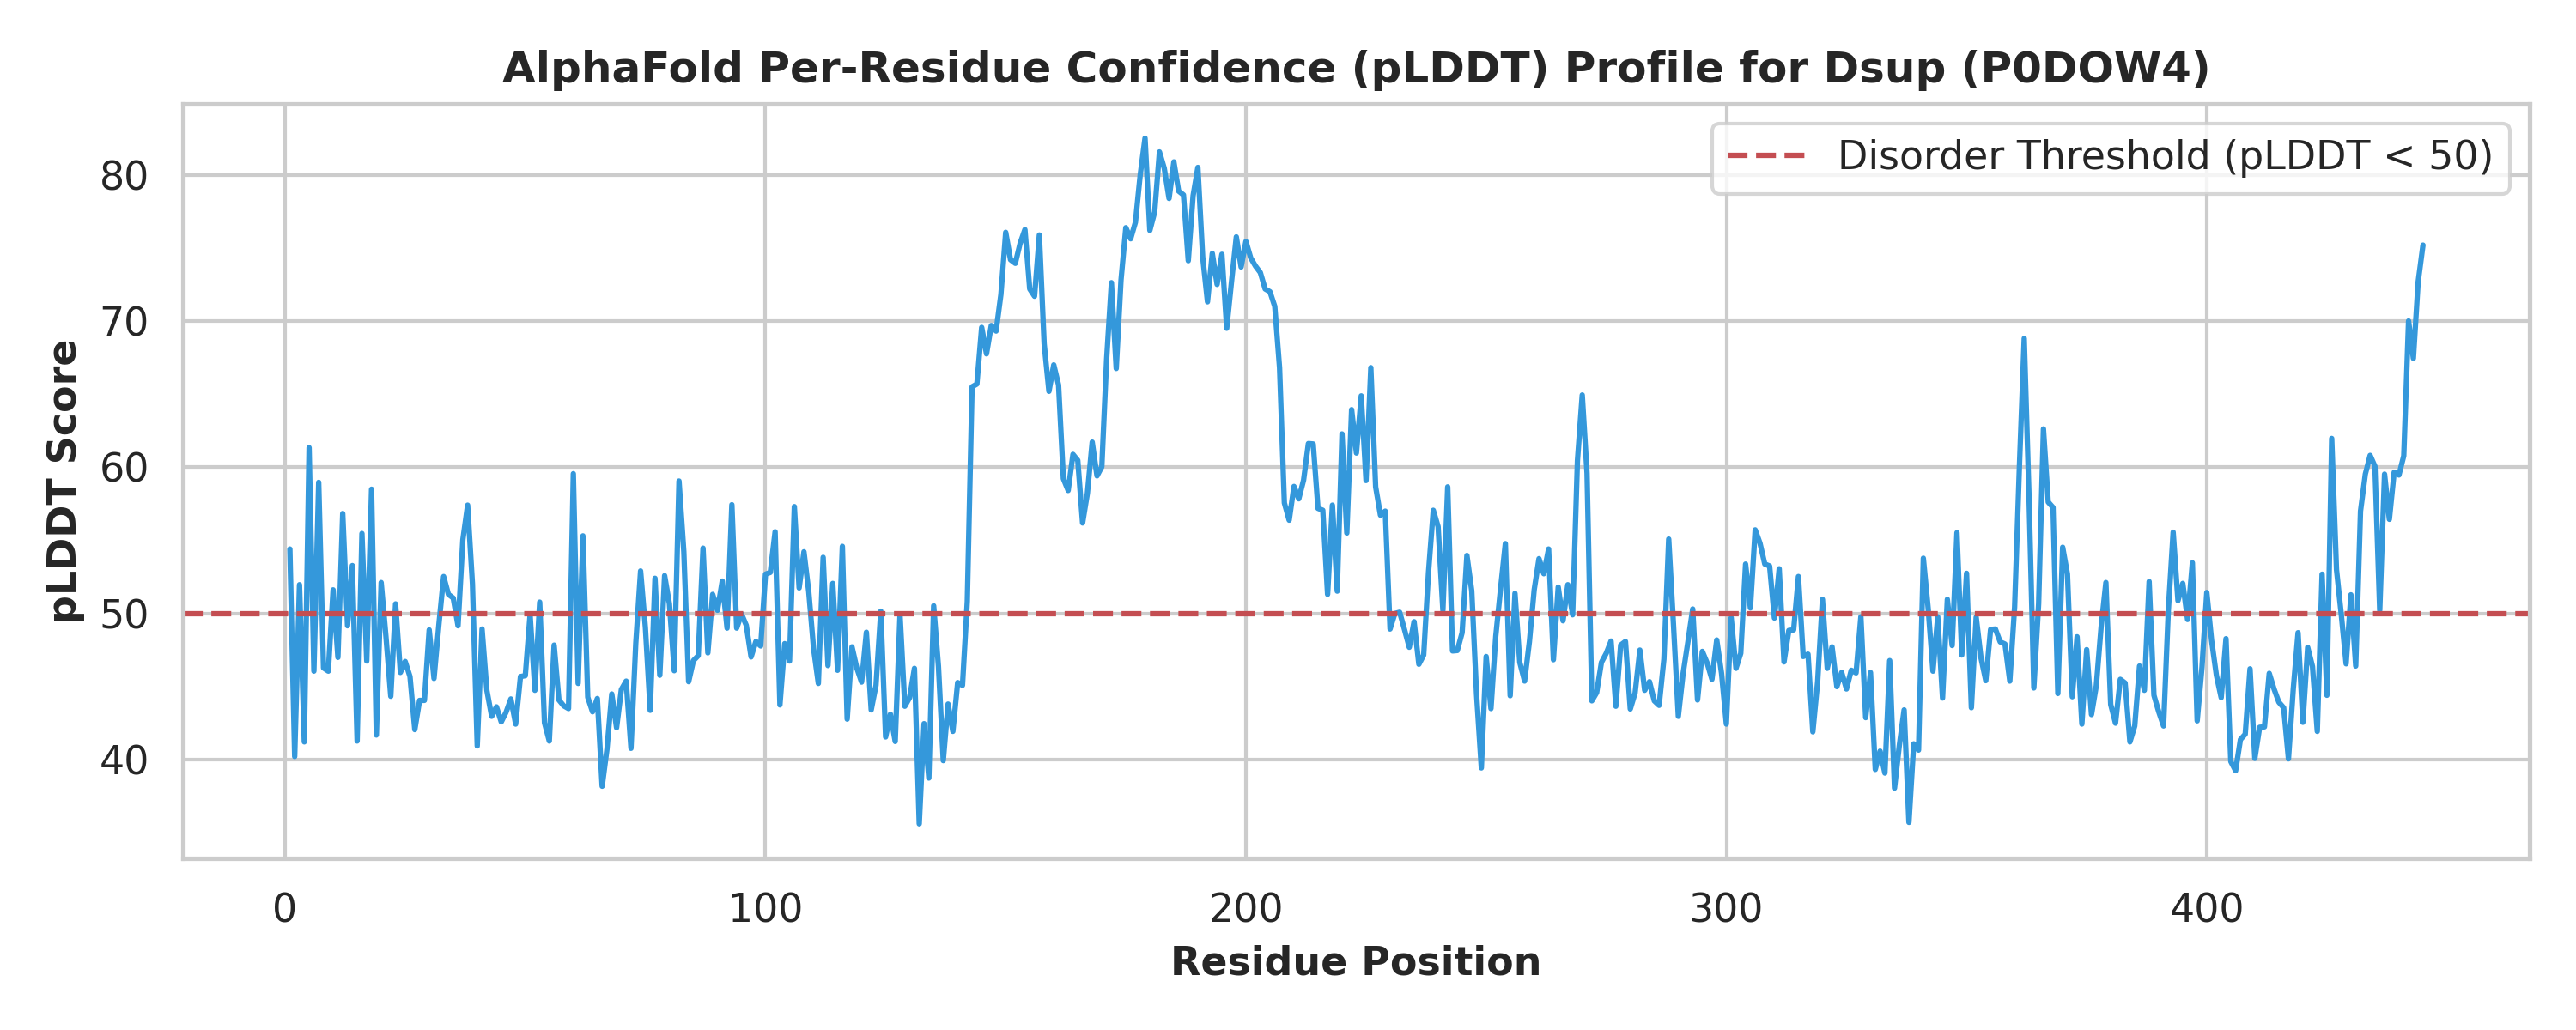

In [ ]:
from Bio.PDB import PDBParser
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Parse the downloaded AlphaFold structure
parser = PDBParser(QUIET=True)
structure = parser.get_structure("Dsup", "AF-P0DOW4-F1.pdb")

residues = []
plddt_scores = []

for model in structure:
    for chain in model:
        for residue in chain:
            if 'CA' in residue:
                residues.append(residue.get_id()[1])
                # AlphaFold stores pLDDT confidence in the B-factor field
                plddt_scores.append(residue['CA'].get_bfactor())

avg_plddt = np.mean(plddt_scores)
disordered_count = sum(1 for score in plddt_scores if score < 50)
disordered_pct = (disordered_count / len(plddt_scores)) * 100

print(f"Average pLDDT Confidence Score: {avg_plddt:.2f}")
print(f"Percentage of Disordered Residues (pLDDT < 50): {disordered_pct:.2f}%")

# Plot pLDDT confidence profile
plt.figure(figsize=(10, 4))
plt.plot(residues, plddt_scores, color='#3498db', lw=1.5)
plt.axhline(y=50, color='r', linestyle='--', label='Disorder Threshold (pLDDT < 50)')
plt.xlabel('Residue Position', fontsize=11, fontweight='bold')
plt.ylabel('pLDDT Score', fontsize=11, fontweight='bold')
plt.title('AlphaFold Per-Residue Confidence (pLDDT) Profile for Dsup (P0DOW4)', fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('dsup_plddt_profile.png', dpi=300)
plt.close()

print("pLDDT profile generated successfully! Displaying chart:\n")
display(Image("dsup_plddt_profile.png"))

Sliding-window analysis complete! Displaying density profile:



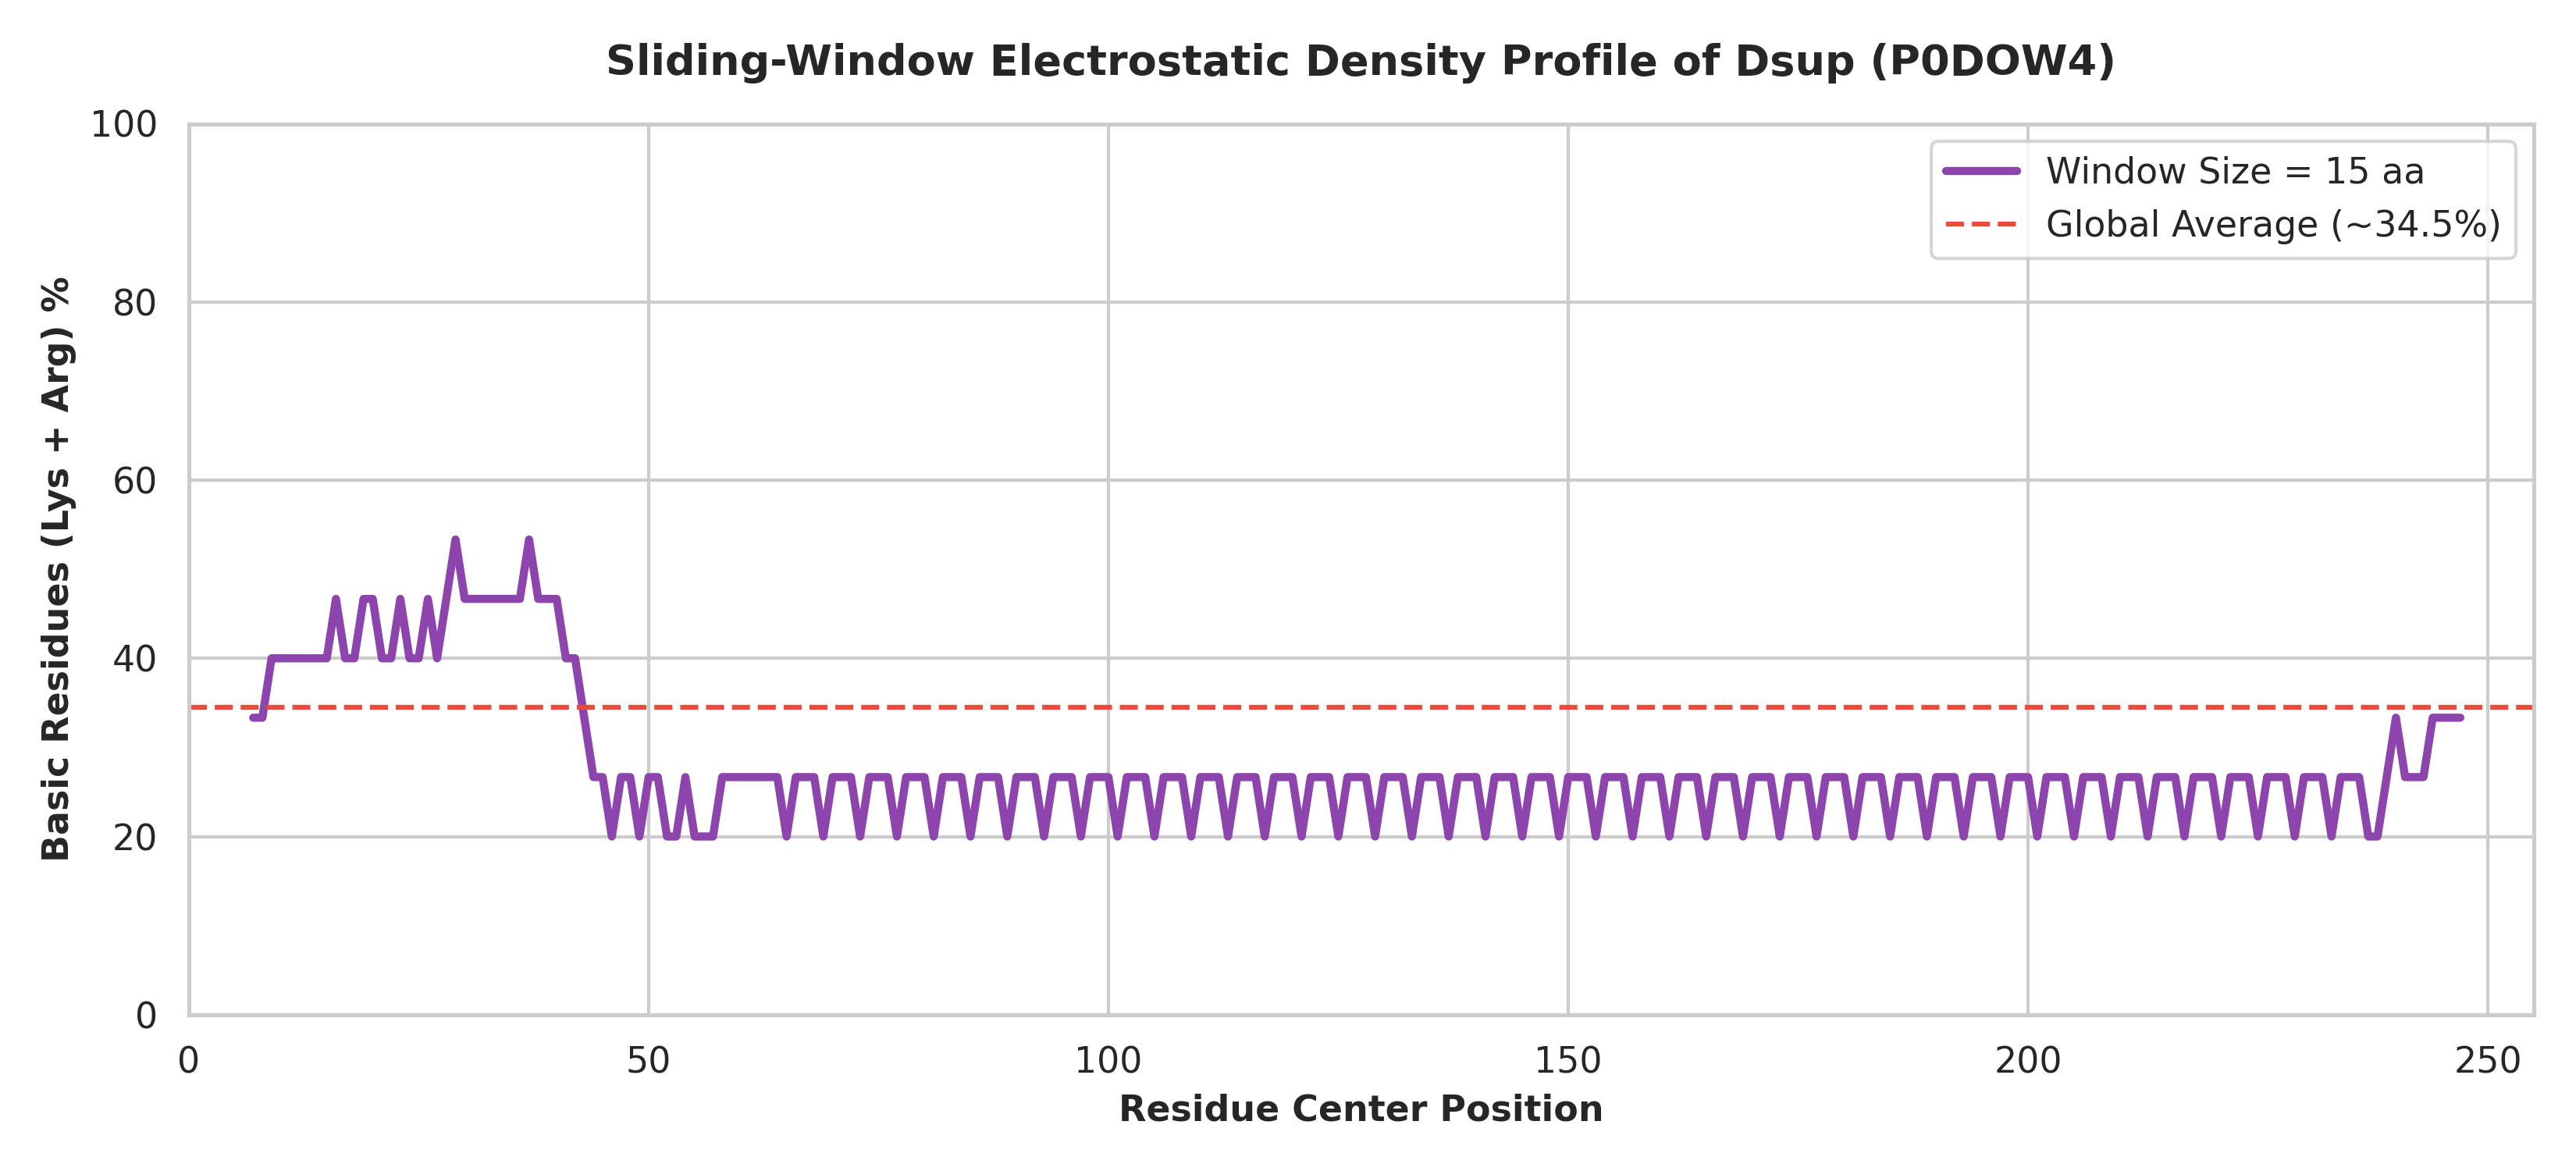

In [ ]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

# 1. Target Sequence (Ramazzottius varieornatus Dsup)
dsup_seq = "MNKQKSTRGRGGSRGARRGRGARRGGRGGSRGRKARRGKAGRNSKEDKDSDEDEKESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESKDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRAAAAKKTAAKKTA"

# 2. Sliding Window Parameters
window_size = 15  # Number of amino acids per window
positions = []
basic_percentages = []

# 3. Compute Sliding Window Basic Residue Density (Lys + Arg)
for i in range(len(dsup_seq) - window_size + 1):
    window = dsup_seq[i:i + window_size]
    basic_count = window.count('K') + window.count('R')
    percentage = (basic_count / window_size) * 100.0

    # Use the center of the window as the position index
    center_pos = i + (window_size // 2)
    positions.append(center_pos)
    basic_percentages.append(percentage)

# 4. Plotting the Sliding Window Profile
plt.figure(figsize=(11, 5))
sns.set_theme(style="whitegrid")

plt.plot(positions, basic_percentages, color='#8e44ad', linewidth=2.5, label=f'Window Size = {window_size} aa')
plt.axhline(y=34.5, color='#e74c3c', linestyle='--', label='Global Average (~34.5%)')

plt.xlabel('Residue Center Position', fontsize=11, fontweight='bold')
plt.ylabel('Basic Residues (Lys + Arg) %', fontsize=11, fontweight='bold')
plt.title('Sliding-Window Electrostatic Density Profile of Dsup (P0DOW4)', fontsize=13, fontweight='bold', pad=15)
plt.legend(loc='upper right')

plt.xlim(0, len(dsup_seq))
plt.ylim(0, 100)
plt.tight_layout()

plt.savefig('dsup_sliding_window_basic_density.png', dpi=300)
plt.close()

print("Sliding-window analysis complete! Displaying density profile:\n")
display(Image("dsup_sliding_window_basic_density.png"))

In [ ]:
from Bio import PDB
import numpy as np

# 1. Target Sequence & Sliding-Window Parameters
dsup_seq = "MNKQKSTRGRGGSRGARRGRGARRGGRGGSRGRKARRGKAGRNSKEDKDSDEDEKESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESKDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRDEEKEESKDESRAAAAKKTAAKKTA"
window_size = 15

# Compute sliding window basic percentages
basic_density_map = {}
for i in range(len(dsup_seq) - window_size + 1):
    window = dsup_seq[i:i + window_size]
    basic_count = window.count('K') + window.count('R')
    pct = (basic_count / window_size) * 100.0
    # Assign the sliding window average to each residue in the window
    for pos in range(i, i + window_size):
        if pos not in basic_density_map:
            basic_density_map[pos] = []
        basic_density_map[pos].append(pct)

# Average overlapping scores
final_density_scores = {pos: np.mean(scores) for pos, scores in basic_density_map.items()}

# 2. Parse Existing AlphaFold Structure
parser = PDBParser(QUIET=True)
structure = parser.get_structure("Dsup", "AF-P0DOW4-F1.pdb")

# 3. Overwrite B-factor Column with Basic Residue Density Values
residue_index = 0
for model in structure:
    for chain in model:
        for residue in chain:
            # Check if it's a standard amino acid residue
            if PDB.is_aa(residue, standard=True):
                if residue_index in final_density_scores:
                    score = final_density_scores[residue_index]
                else:
                    score = 0.0 # Default fallback for terminals

                # Update B-factor for all atoms in the residue so the whole sidechain inherits the score
                for atom in residue:
                    atom.set_bfactor(score)

                residue_index += 1

# 4. Save Modified PDB File
io = PDB.PDBIO()
io.set_structure(structure)
io.save("dsup_electrostatic_mapped.pdb")

print("Successfully mapped basic residue density into B-factor column!")
print("Saved modified structure as: dsup_electrostatic_mapped.pdb")

Successfully mapped basic residue density into B-factor column!
Saved modified structure as: dsup_electrostatic_mapped.pdb


In [ ]:
readme_content = """# 🧬 Comparative Genomics and Structural Biophysics of Tardigrade Stress Proteins

A comprehensive computational pipeline exploring the evolutionary divergence, electrostatic shielding, and intrinsic disorder of extremotolerant tardigrade proteins (*Ramazzottius varieornatus* and *Hypsibius exemplaris*) relative to model metazoan organisms.

## 📌 Project Overview
Tardigrades exhibit extraordinary tolerance to ionizing radiation, extreme desiccation, and oxidative stress. This repository contains automated Python scripts to:
1. **Construct Multi-FASTA datasets** of stress-resilient proteins (Dsup, CAHS1) alongside mitochondrial antioxidant orthologs (MnSOD).
2. **Compute global sequence identity matrices** and neighbor-joining phylogenetic trees.
3. **Quantify biophysical properties** (molecular weight, theoretical isoelectric points, and basic amino acid enrichment) using Biopython.
4. **Analyze AlphaFold 3D structures** to evaluate per-residue confidence (pLDDT) and intrinsic disorder (IDR).
5. **Map electrostatic sliding-window basic residue densities** directly into PDB B-factor columns for structural visualization.

## 🗂️ Repository Structure
- `extremophile_targets.fasta` - Multi-FASTA database
- `sequence_identity_matrix.csv` - Pairwise percentage identity matrix
- `biophysical_properties.csv` - Molecular weights, pI, and basic residue percentages
- `dsup_electrostatic_mapped.pdb` - Custom PDB with electrostatic sliding-window scores in B-factor
"""

with open("README.md", "w") as f:
    f.write(readme_content)

print("README.md successfully created and saved to your workspace!")

README.md successfully created and saved to your workspace!


In [ ]:
pip install biopython pandas numpy matplotlib seaborn requests

In [ ]:
import glob
import zipfile
from google.colab import files

zip_filename = "comparative_genomics_results.zip"
file_patterns = ["*.csv", "*.png", "*.pdb", "*.fasta", "*.md"]

print("Compressing generated project files into a zip archive...")
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for pattern in file_patterns:
        for file_path in glob.glob(pattern):
            zipf.write(file_path)
            print(f"  + Added: {file_path}")

print(f"\nArchive created: {zip_filename}")
print("Triggering browser download...")

# Automatically prompt download in Colab
files.download(zip_filename)

Compressing generated project files into a zip archive...
  + Added: sequence_identity_matrix.csv
  + Added: biophysical_properties.csv
  + Added: dsup_plddt_profile.png
  + Added: conservation_heatmap.png
  + Added: dsup_sliding_window_basic_density.png
  + Added: phylogenetic_tree.png
  + Added: basic_residue_enrichment.png
  + Added: dsup_electrostatic_mapped.pdb
  + Added: AF-P0DOW4-F1.pdb
  + Added: extremophile_targets.fasta
  + Added: README.md

Archive created: comparative_genomics_results.zip
Triggering browser download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>